In [1]:
# Preregistered Analyses

# Self-contained snapshot for pre-registration, copied from hub_experiment/analysis_v3.ipynb.
# All data/array dependencies are bundled locally in this directory (see CONFIG cell below).

# Implements analysis_implementation_spec.md (BSCV approach of Baker et al. 2017):
#   Analysis 1: within-set generalization  — leave-one-scenario-out per set,
#               then bootstrap the pooled out-of-sample predictions (no refit)
#   Analysis 2: across-type generalization — leave-one-set-out, per-fold table,
#               then bootstrap the pooled 60-scenario predictions (no refit)
#   Analysis 3: novel-scenario generalization — 100 random 45/15 splits, refit
#               on every split
#   §5:         parameter estimates per set and over all 60 scenarios
#
# Statistics follow the spec: the point estimate is the MEDIAN R² with a
# 2.5/97.5 percentile CI, models are compared by win rate and paired
# differences, and NO t-tests or p-values are computed — bootstrap replicates
# are not independent observations, so a p-value would track the resample
# count rather than the data.
#
# Models (spec numbering): M1 Full (7 params) | M2 HP goodness (Halpern &
# Pearl 2005b) | M3 No-inference | M4 No-future (γ=0) | M5 No-social.

In [2]:
%matplotlib inline

import os
import json
import numpy as np
import jax
import jax.numpy as jnp
from jax import lax
import jax.nn as nn
import matplotlib.pyplot as plt
import optax
from typing import NamedTuple, no_type_check
from functools import cache
from memo import memo

print(f"JAX {jax.__version__}  devices={jax.devices()}")


JAX 0.8.2  devices=[CpuDevice(id=0)]


In [3]:
# ============================================================
# CONFIG — paths relative to this notebook's own directory (explanations_fullstudy/)
# ============================================================
LOG_FILE_ORIG = "pilot_logs/log_orig_remote_20260707_103155.jsonl"
LOG_FILE_L1   = "pilot_logs/log_l1_remote_20260707_103155.jsonl"
LOG_FILE_L2   = "pilot_logs/log_l2_remote_20260707_103155.jsonl"
LOG_FILE_L3   = "pilot_logs/log_l3_remote_20260707_103155.jsonl"
ARRAY_DIR     = "."   # this directory — contains q_hub.npy, state_tr_hub.npy, etc.


In [4]:
# ============================================================
# WORLD MAPS — grid layouts for both maps
# Pure geometry: tile-type grids and landmark positions. No model logic here
# -- see the DISPLAY BOTH MAPS cell below for a visualization, and the
# modeling-code cells further down for the transition/reward functions
# that operate on these grids.
# ============================================================

_ORIG_ROWS, _ORIG_COLS = 6, 9
_N_STATES_ORIG         = 54
_ORIG_WM_IDX           = 45   # WestMart (5,0)
_ORIG_EM_IDX           = 50   # EastMart (5,5)
_ORIG_BANK_IDX         = 20   # Bank     (2,2)
_ORIG_ATM_IDX          = 8    # ATM      (0,8)

# Tile legend: 0=free 1=trees 2=westmart 3=eastmart 4=bank 5=atm 6=main_street
worldmap_orig = jnp.zeros((_ORIG_ROWS, _ORIG_COLS))
worldmap_orig = worldmap_orig.at[1, 1:5].set(1)
worldmap_orig = worldmap_orig.at[1:6, 4].set(1)
worldmap_orig = worldmap_orig.at[2, 3].set(1)
worldmap_orig = worldmap_orig.at[3:5, 1].set(1)
worldmap_orig = worldmap_orig.at[4, 2].set(1)
worldmap_orig = worldmap_orig.at[1:5, 6].set(1)
worldmap_orig = worldmap_orig.at[1:5, 8].set(1)
worldmap_orig = worldmap_orig.at[1, 7].set(1)
worldmap_orig = worldmap_orig.at[4, 7].set(1)
worldmap_orig = worldmap_orig.at[5, 0].set(2)   # WestMart
worldmap_orig = worldmap_orig.at[5, 5].set(3)   # EastMart
worldmap_orig = worldmap_orig.at[2, 2].set(4)   # Bank
worldmap_orig = worldmap_orig.at[0, 8].set(5)   # ATM
worldmap_orig = worldmap_orig.at[1:5, 5].set(6) # Main Street
flatmap_orig  = worldmap_orig.reshape(-1)

_HUB_ROWS, _HUB_COLS = 9, 10
_N_STATES_HUB        = 90
_HUB_WM_IDX          = 71   # WestMart  (7,1)
_HUB_EM_IDX          = 78   # EastMart  (7,8)
_HUB_BANK_IDX        = 18   # Bank      (1,8)
_HUB_ATM_IDX         = 52   # ATM       (5,2)

hub_flatmap_jnp       = jnp.array(np.load(os.path.join(ARRAY_DIR, "hub_flatmap.npy")))   # (90,)

print(f"Orig map:  {_ORIG_ROWS}x{_ORIG_COLS} = {_N_STATES_ORIG} states")
print(f"Hub map:   {_HUB_ROWS}x{_HUB_COLS} = {_N_STATES_HUB} states")


Orig map:  6x9 = 54 states
Hub map:   9x10 = 90 states


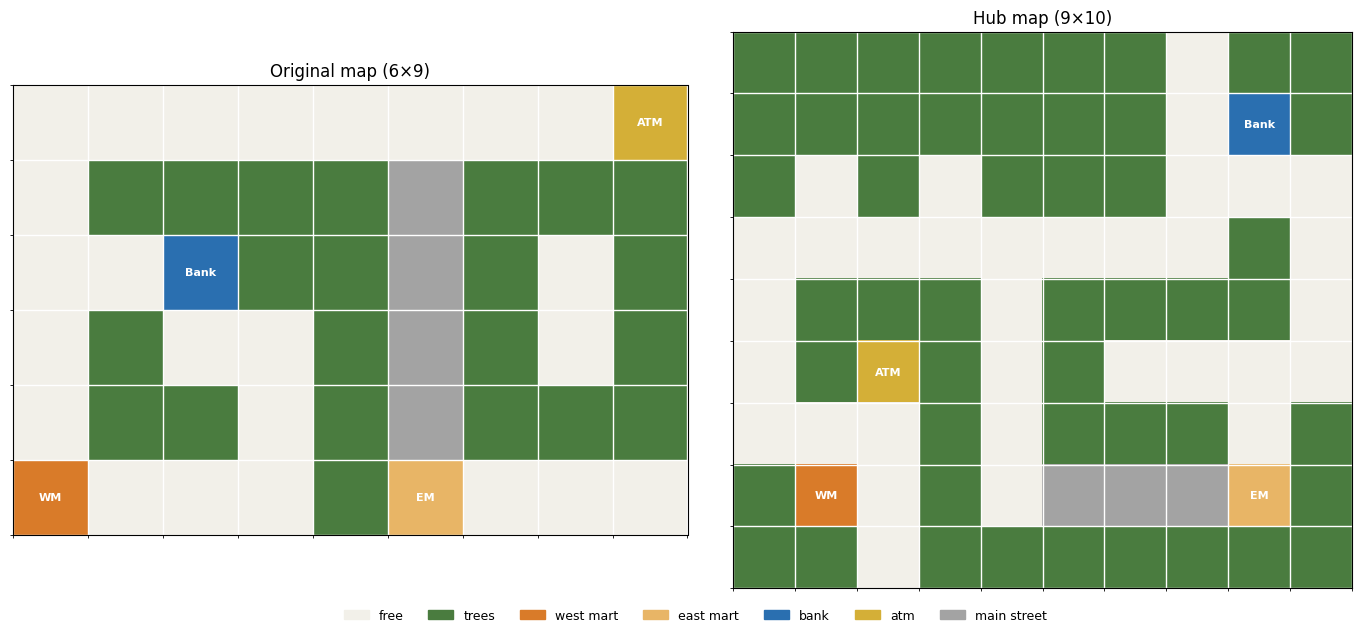

Saved world_maps.png


In [5]:
# ============================================================
# DISPLAY BOTH MAPS
# ============================================================

import matplotlib.colors as mcolors

_TILE_COLORS = {
    "free":        "#f2f0e9",
    "trees":       "#4a7c3f",
    "west mart":   "#d97b29",
    "east mart":   "#e8b566",
    "bank":        "#2a6fb0",
    "atm":         "#d4af37",
    "main street": "#a3a3a3",
}

def _tile_legend(flat_grid, wm_idx, em_idx, bank_idx, atm_idx):
    """Map each tile CODE to its semantic label, read off the grid at the
    known landmark indices (the numeric code for west/east mart differs
    between the orig and hub maps, so this is derived rather than assumed)."""
    flat = np.array(flat_grid).reshape(-1).astype(int)
    legend = {0: "free", 1: "trees", 6: "main street"}
    legend[int(flat[wm_idx])]   = "west mart"
    legend[int(flat[em_idx])]   = "east mart"
    legend[int(flat[bank_idx])] = "bank"
    legend[int(flat[atm_idx])]  = "atm"
    return legend

def _draw_map(ax, grid, rows, cols, wm_idx, em_idx, bank_idx, atm_idx, title):
    grid_arr = np.array(grid).reshape(rows, cols).astype(int)
    legend   = _tile_legend(grid_arr, wm_idx, em_idx, bank_idx, atm_idx)
    rgb = np.zeros((rows, cols, 3))
    for code, name in legend.items():
        rgb[grid_arr == code] = mcolors.to_rgb(_TILE_COLORS[name])
    ax.imshow(rgb, origin="upper")
    ax.set_xticks(np.arange(-0.5, cols, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, rows, 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=1)
    ax.set_xticks([]); ax.set_yticks([])
    for idx, label in [(wm_idx, "WM"), (em_idx, "EM"), (bank_idx, "Bank"), (atm_idx, "ATM")]:
        r, c = idx // cols, idx % cols
        ax.text(c, r, label, ha="center", va="center", fontsize=8,
                fontweight="bold", color="white")
    ax.set_title(title, fontsize=12)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
_draw_map(axes[0], worldmap_orig, _ORIG_ROWS, _ORIG_COLS,
          _ORIG_WM_IDX, _ORIG_EM_IDX, _ORIG_BANK_IDX, _ORIG_ATM_IDX,
          f"Original map ({_ORIG_ROWS}\u00d7{_ORIG_COLS})")
_draw_map(axes[1], hub_flatmap_jnp, _HUB_ROWS, _HUB_COLS,
          _HUB_WM_IDX, _HUB_EM_IDX, _HUB_BANK_IDX, _HUB_ATM_IDX,
          f"Hub map ({_HUB_ROWS}\u00d7{_HUB_COLS})")

_handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in _TILE_COLORS.values()]
fig.legend(_handles, list(_TILE_COLORS.keys()), loc="lower center", ncol=7,
           fontsize=9, frameon=False, bbox_to_anchor=(0.5, -0.05))
plt.tight_layout()
plt.savefig("world_maps.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved world_maps.png")


In [6]:
# ============================================================
# WORLD MODEL CONSTANTS (shared by both maps)
# ============================================================

S_orig = jnp.arange(_N_STATES_ORIG)
# State / action spaces
S_hub = jnp.arange(_N_STATES_HUB)
A     = jnp.arange(5)   # UP=0, DOWN=1, LEFT=2, RIGHT=3, COLLECT_CASH=4
M     = jnp.arange(16)
U     = jnp.arange(81)
coord_actions = jnp.array([[-1, 0], [+1, 0], [0, -1], [0, +1]])

# 16 world models [ST, CA, MA, SK]
condition_models = jnp.array(
    [[ST, CA, MA, SK]
     for ST in range(2) for CA in range(2)
     for MA in range(2) for SK in range(2)]
)
model_id_lookup = {tuple(int(v) for v in condition_models[m]): int(m) for m in range(16)}

# 81 utterances [ST, CA, MA, SK] in {false=0, true=1, not-mentioned=2}
utterances    = jnp.array(
    [[ST, CA, MA, SK]
     for ST in range(3) for CA in range(3)
     for MA in range(3) for SK in range(3)]
)
utterances_np = np.array(utterances)

# mention_matrix[u, f] = 1 if utterance u mentions feature f
mention_matrix = jnp.array([(utterances[u] != 2).astype(int) for u in range(81)])

# Model-utterance transitions: Bob's updated belief after hearing utterance u
_mut = np.zeros((16, 81), dtype=int)
for _m in range(16):
    _st, _ca, _ma, _sk = (int(v) for v in condition_models[_m])
    for _u in range(81):
        _su, _cu, _mu, _ku = (int(v) for v in utterances[_u])
        _key = (_st if _su == 2 else _su, _ca if _cu == 2 else _cu,
                _ma if _mu == 2 else _mu, _sk if _ku == 2 else _ku)
        _mut[_m, _u] = model_id_lookup[_key]
model_utterance_transitions = jnp.array(_mut)

# Feature helpers
cash_models     = jnp.array([1,1,1,1,0,0,0,0,1,1,1,1,0,0,0,0])
westmart_models = jnp.array([1,1,0,0,1,1,0,0,1,1,0,0,1,1,0,0])

@jax.jit
def have_cash(m):     return cash_models[m] == 1
@jax.jit
def westmart_open(m): return westmart_models[m] == 1

@jax.jit
def get_feature_probs_clean(utt_probs):
    return utt_probs @ mention_matrix

def parse_condition_string(cond_str):
    st = int(cond_str[2]); ca = int(cond_str[5])
    ma = int(cond_str[8]); sk = int(cond_str[11])
    return model_id_lookup[(st, ca, ma, sk)]

FEATURE_NAMES = ["ST", "CA", "MA", "SK"]

print(f"World model constants ready.  {len(M)} models | {len(U)} utterances")


World model constants ready.  16 models | 81 utterances


In [7]:
# ============================================================
# ORIG MODEL MECHANICS — transitions, termination, reward (6×9 map)
# ============================================================

# Load pre-computed transitions (saved by explain_mdp_v5.ipynb)
state_transitions_orig = jnp.array(np.load(os.path.join(ARRAY_DIR, "state_tr_orig.npy")))  # (54, 5, 16)
model_transitions_orig = jnp.array(np.load(os.path.join(ARRAY_DIR, "model_tr_orig.npy")))  # (16, 54, 5)

@jax.jit
def Tr_state_orig(s, a, m, s_):
    return 1.0 * (s_ == state_transitions_orig[s, a, m])

@jax.jit
def Tr_model_orig(m, s, a, m_):
    return 1.0 * (m_ == model_transitions_orig[m, s, a])

@jax.jit
def is_terminating_orig(s, m):
    return 1.0 * (
        ((s == _ORIG_WM_IDX) & (westmart_models[m] == 1) & (cash_models[m] == 1)) |
        ((s == _ORIG_EM_IDX) & (cash_models[m] == 1))
    )

@jax.jit
def R_orig(s, m):
    return 1.0 * (is_terminating_orig(s, m) - 0.1)

# Model/utterance structures are identical to hub — alias rather than duplicate
condition_models_orig            = condition_models
model_id_lookup_orig             = model_id_lookup
utterances_orig                  = utterances
utterances_orig_np               = utterances_np
mention_matrix_orig              = mention_matrix
cash_models_orig                 = cash_models
westmart_models_orig             = westmart_models
model_utterance_transitions_orig = model_utterance_transitions

ORIG_FEATURE_NAMES = ["ST", "CA", "MA", "SK"]

def optimal_path_orig(Q, s0, m0, max_steps=80):
    traj, s, m = [], s0, m0
    for _ in range(max_steps):
        if float(is_terminating_orig(s, m)) > 0.5:
            break
        a   = int(jnp.argmax(Q[s, m, :]))
        s_  = int(state_transitions_orig[s, a, m])
        m_  = int(model_transitions_orig[m, s, a])
        traj.append((s, m, a, s_, m_))
        s, m = s_, m_
    return traj or [(s0, m0, 0, s0, m0)]

print("Orig model mechanics ready.")


Orig model mechanics ready.


In [8]:
# ============================================================
# HUB MODEL MECHANICS — transitions, termination, reward (9×10 map)
# ============================================================

# ============================================================
# STATE / MODEL TRANSITIONS — loaded from pre-computed .npy
# ============================================================

def next_position_from_hub(position, a):
    if a == 4:
        return position
    row  = position // _HUB_COLS
    col  = position % _HUB_COLS
    drow, dcol = int(coord_actions[a, 0]), int(coord_actions[a, 1])
    nrow = int(jnp.clip(row + drow, 0, _HUB_ROWS - 1))
    ncol = int(jnp.clip(col + dcol, 0, _HUB_COLS - 1))
    return _HUB_COLS * nrow + ncol

state_transitions_hub = jnp.array(np.load(os.path.join(ARRAY_DIR, "state_tr_hub.npy")))  # (90, 5, 16)
model_transitions_hub = jnp.array(np.load(os.path.join(ARRAY_DIR, "model_tr_hub.npy")))  # (16, 90, 5)

@jax.jit
def Tr_state_hub(s, a, m, s_):
    return 1.0 * (s_ == state_transitions_hub[s, a, m])

@jax.jit
def Tr_model_hub(m, s, a, m_):
    return 1.0 * (m_ == model_transitions_hub[m, s, a])

print("Transitions ready.")

@jax.jit
def is_terminating_hub(s, m):
    return 1.0 * (
        ((s == _HUB_WM_IDX) & westmart_open(m) & have_cash(m)) |
        ((s == _HUB_EM_IDX) & have_cash(m))
    )

@jax.jit
def R_hub(s, m):
    return 1.0 * (is_terminating_hub(s, m) - 0.1)

GAMMA_PLAN = 1.0
BETA_PLAN  = 2.0
MAX_PATH   = 50

def optimal_path_hub(Q, s0, m0, max_steps=80):
    traj, s, m = [], s0, m0
    for _ in range(max_steps):
        if float(is_terminating_hub(s, m)) > 0.5:
            break
        a  = int(jnp.argmax(Q[s, m, :]))
        s_ = int(state_transitions_hub[s, a, m])
        m_ = int(model_transitions_hub[m, s, a])
        traj.append((s, m, a, s_, m_))
        s, m = s_, m_
    return traj or [(s0, m0, 0, s0, m0)]

print("Hub model mechanics ready.")


Transitions ready.
Hub model mechanics ready.


In [9]:
# ============================================================
# SHARED JAX HELPERS — belief updates + utterance scoring (used by both maps)
# ============================================================

@jax.jit
def get_initial_model_beliefs(prior):
    priors = jnp.concatenate([jnp.array([1.0]), jnp.full(15, prior)])
    return priors / jnp.sum(priors)

@jax.jit
def p_ask_step(move_probs, s, m, a, p_c, p_s):
    ap = move_probs[s, m, :]
    return jnp.where(ap[a] >= (jnp.max(ap) - 1e-6), p_s, p_c)

@jax.jit
def update_beliefs(beliefs, move_probs, s, a, did_ask, p_c, p_s):
    liks = jnp.array([
        jnp.where(did_ask == 1,
                  p_ask_step(move_probs, s, m, a, p_c, p_s),
                  1.0 - p_ask_step(move_probs, s, m, a, p_c, p_s))
        for m in range(16)
    ])
    unnorm = beliefs * liks
    return unnorm / (jnp.sum(unnorm) + 1e-10)

@jax.jit
def utterance_is_true(u, true_model):
    utt = utterances[u]; mod = condition_models[true_model]
    return 1.0 * jnp.all((utt == 2) | (utt == mod))

@jax.jit
def utterance_cost(u, lc, sc, model_probs):
    utt    = utterances[u]
    length = jnp.sum(utt != 2)
    social = sum(
        model_probs[m] * sum(1 * (condition_models[m][i] == utt[i]) for i in range(4))
        for m in range(16)
    )
    return lc * length + sc * social

print("Shared jax helpers ready.")


Shared jax helpers ready.


In [10]:
# ============================================================
# ORIG BELIEF + UTTERANCE-VALUE FUNCTIONS
# ============================================================

# ============================================================
# compute_model_beliefs_orig -- Bob's posterior belief over all 16 world
# models, formed by "replaying" Alice's actual walk one step at a time and
# treating Bob's ask / don't-ask behaviour at each step as Bayesian evidence.
#
# Alice never observes Bob's beliefs directly -- this function is Alice's
# SIMULATION of what a Bayesian-reasoning Bob would come to believe, given
# that he watched her take this specific path. It produces the belief vector
# that alice_guesses_model_orig (in the @memo cell below) turns into `mb`,
# which alice_chooses_utterance_orig then conditions its utterance choice on.
#
# Arguments:
#   prior      -- relative prior weight Bob is assumed to place on any ONE of
#                 the 15 "something unusual is going on" models, versus model
#                 index 0 ("nothing unusual"). Passed straight into
#                 get_initial_model_beliefs, which builds the length-16 vector
#                 [1.0, prior, prior, ..., prior] and normalizes it to sum to
#                 1 -- this is the belief BEFORE any of Alice's actions are
#                 observed.
#   move_probs -- softmax(BETA_PLAN * Q), shape (n_states, 16, n_actions).
#                 move_probs[s, m, a] = probability a rational planner would
#                 take action a from state s if model m were true. Used both
#                 to generate Alice's own actual actions (looked up at the
#                 TRUE model) and, for every OTHER candidate model m', to ask
#                 "would that action have looked expected under m'?".
#   start_s    -- Alice's starting grid state for this leg of the walk
#                 (stim.start_state_pre).
#   start_m    -- the TRUE world-model index for this scenario
#                 (stim.true_model). This seeds the `m` slot of the loop
#                 carry; despite the name "start", note below that m CAN
#                 change mid-walk.
#   n_steps    -- length of the "pre-ask" portion of the walk
#                 (stim.n_steps_pre). Bob is modeled as literally asking a
#                 question on exactly one step, i == n_steps - 1 (the last
#                 step before the explain moment); every other step he
#                 silently does NOT ask, and that silence is itself evidence.
#   p_c        -- "curious" ask rate: P(Bob asks | Alice's action was a
#                 SURPRISE under some candidate model, i.e. not that model's
#                 argmax action).
#   p_s        -- "spurious" ask rate: P(Bob asks | Alice's action was fully
#                 EXPECTED under some candidate model) -- a baseline
#                 false-alarm rate, independent of anything actually being
#                 wrong.
#
# Per-step mechanics (step_fn, driven by lax.fori_loop over i = 0..MAX_PATH_ORIG-1
# carrying (beliefs, s, m)):
#   a       = argmax(move_probs[s, m, :])
#             The action Alice actually takes at this step (m here is always
#             the true model, since m only ever changes via
#             model_transitions_orig -- see below -- and start_m is correct).
#   did_ask = 1 only when i == n_steps - 1, else 0 -- see n_steps above.
#   update_beliefs(beliefs, move_probs, s, a, did_ask, p_c, p_s):
#             one Bayesian update. For each of the 16 candidate models m',
#             p_ask_step(...) returns p_s if `a` matches m''s optimal
#             action at s (expected) or p_c if it doesn't (surprising); this
#             becomes the likelihood of Bob asking under m'. If did_ask == 0
#             the likelihood used is (1 - that) instead -- the likelihood of
#             Bob NOT asking. `beliefs` is multiplied elementwise by these 16
#             likelihoods and renormalized. Because this runs on EVERY step
#             (not only the literal ask step), every action Alice takes
#             contributes evidence via the "he didn't ask" likelihood, even
#             though Bob only explicitly asks once.
#   beliefs = jnp.where(i < n_steps, new_b, beliefs)
#             Freezes the belief vector once the walk passes n_steps; the
#             remaining iterations up to the JIT-static bound MAX_PATH_ORIG are
#             no-ops for the belief itself (lax.fori_loop needs a fixed
#             iteration count, so we just let it run and discard the tail).
#   (s, m) advance every iteration via state_transitions_orig[s,a,m] /
#             model_transitions_orig[m,s,a], regardless of n_steps. m is
#             usually unchanged by this (model_transitions_orig is the
#             identity for ~99.7% of (m,s,a) combos) but DOES change at a
#             handful of specific (state, action) "checkpoint" combos -- e.g.
#             interacting with the ATM or Bank tile resolves the CA
#             (needs-cash) or SK (bank-strike) condition, collapsing to a
#             different model index. That's why m is threaded through the
#             carry rather than being treated as a constant.
#
# Returns: `final`, the length-16 posterior belief vector after the whole
# (up to MAX_PATH_ORIG-step) simulated walk -- final[m] = Alice's estimate of
# Pr(Bob currently believes the true model is m | everything he watched her
# do, including choosing not to ask at every step but the last).
#
# compute_beliefs_single_model_orig -- thin wrapper around the above: it runs
# the full 16-model posterior computed by compute_model_beliefs_orig and picks
# out entry `m`. It exists because alice_guesses_model_orig (@memo, below)
# needs a function of a single output index m to build the belief
# distribution one component at a time; all the real work happens above.
# ============================================================
@jax.jit
def compute_model_beliefs_orig(prior, move_probs, start_s, start_m, n_steps, p_c, p_s):
    init = get_initial_model_beliefs(prior)
    def step_fn(i, carry):
        beliefs, s, m = carry
        a       = jnp.argmax(move_probs[s, m, :])
        did_ask = (i == n_steps - 1).astype(jnp.int32)
        new_b   = update_beliefs(beliefs, move_probs, s, a, did_ask, p_c, p_s)
        beliefs = jnp.where(i < n_steps, new_b, beliefs)
        return (beliefs, state_transitions_orig[s, a, m], model_transitions_orig[m, s, a])
    final, _, _ = lax.fori_loop(0, MAX_PATH_ORIG, step_fn, (init, start_s, start_m))
    return final

@jax.jit
def compute_beliefs_single_model_orig(m, prior, move_probs, start_s, start_m, n_steps, p_c, p_s):
    return compute_model_beliefs_orig(prior, move_probs, start_s, start_m, n_steps, p_c, p_s)[m]

# ============================================================
# utterance_value_iterative_orig -- how informative is utterance u, i.e. how
# well would a listener who updates their belief on hearing u then be able
# to anticipate what Alice actually does next?
#
# High-level idea: for every model `cm` the listener MIGHT currently believe
# (weighted by how likely Alice thinks that is, `model_probs[cm]`), figure
# out what their belief becomes after hearing u (`new_model`), then run TWO
# parallel greedy-policy simulations from the same starting state -- one
# under the TRUE model (what actually happens), one under `new_model` (what
# a listener holding that post-utterance belief would expect to happen) --
# and score how long the two stay in lockstep, penalized for the listener
# still expecting more to happen after the real interaction already ended.
# The expectation over `cm` is then taken using the listener's PRE-utterance
# belief weights, so an utterance is judged by how well it would work across
# every belief state the listener might currently be in.
#
# Arguments:
#   u           -- candidate utterance index (0-80).
#   gamma       -- gamma_utterance, the fitted discount parameter controlling
#                  how much Alice weighs correctly predicting FAR-future
#                  steps vs. just the immediate next one (fac below decays by
#                  this factor every step).
#   Q           -- Q_orig_jnp, precomputed optimal action-values, shape
#                  (n_states, 16, n_actions). argmax(Q[s, m, :]) is the
#                  greedy/optimal action from state s under model m.
#   start_s     -- the state at which the "post-explanation" phase begins
#                  (stim.start_state_post) -- both simulated trajectories
#                  start here.
#   true_m      -- the TRUE world-model index (stim.true_model) -- drives the
#                  "actual" trajectory.
#   n_true      -- number of steps in Alice's real post-explanation path that
#                  we're checking whether a listener could have predicted
#                  (stim.n_steps_post).
#   model_probs -- the listener's belief distribution BEFORE hearing u (this
#                  is `mb`: dynamically inferred by
#                  compute_beliefs_single_model_orig in the full model, or
#                  hard-coded to one-hot on model 0 in the No-inference
#                  lesion).
#
# Outer loop, once per candidate prior model cm in range(16):
#   mp        = model_probs[cm] -- the weight this candidate prior belief
#               contributes to the final expectation.
#   new_model = model_utterance_transitions[cm, u] -- the listener's belief
#               AFTER hearing u: each feature u actually mentions overwrites
#               cm's value for that feature; unmentioned features keep cm's
#               original value (see model_utterance_transitions' construction
#               a few cells up).
#
# Inner loop (cmp_paths, lax.fori_loop over i = 0..MAX_PATH_ORIG-1), carrying two
# simulated trajectories in lockstep:
#   ts, tm  -- TRUE trajectory's current (state, model). Starts at
#              (start_s, true_m).
#   ps, pm  -- PREDICTED/listener trajectory's current (state, model).
#              Starts at (start_s, new_model) -- i.e. this simulates what a
#              listener who now believes new_model would themselves expect
#              to see happen, using the SAME greedy policy Alice uses.
#   t_act   = (~td) & (i < n_true) -- true trajectory is still "in scope":
#              hasn't terminated (td) and we're still within the n_true-step
#              window we're actually comparing against.
#   p_act   = ~pd -- predicted trajectory is still active (no n_true cap here
#              -- a listener can keep "expecting more" past when the real
#              interaction ended).
#   ta, pa  = argmax(Q[ts,tm,:]), argmax(Q[ps,pm,:]) -- the optimal action
#              along each trajectory, evaluated under that trajectory's OWN
#              current model belief.
#   both    = t_act & p_act -- both trajectories are still being compared
#              this step.
#   hits    = (ts == ps) & (ta == pa) -- do the two trajectories currently
#              occupy the same state AND agree on what to do next.
#   still   = jnp.where(both, still * hits, still) -- a "no divergence yet"
#              flag: stays 1 only as long as ts/ta and ps/pa have matched at
#              EVERY step since the start (multiplying by hits=0 zeroes it
#              permanently the first time they disagree; it never resets).
#   tsum    += fac * still, but only while `both` holds -- the accumulated,
#              gamma-discounted count of how many leading steps the listener
#              would have correctly anticipated. This is the "reward" half of
#              the utterance's value: the earlier and longer the predicted
#              path tracks the true one, the higher tsum ends up.
#   rpen    += fac, but only when p_act & (~t_act) -- the listener's
#              simulated self is STILL going (hasn't reached their believed
#              goal) even though the true trajectory has already finished or
#              run out of its n_true budget. This is a "regret" penalty for
#              utterances that leave the listener still expecting the wrong
#              continuation after the real interaction is already over.
#   (ts,tm) and (ps,ps) each advance one step via state_transitions_orig /
#              model_transitions_orig, exactly as in compute_model_beliefs_orig
#              above (including the same rare model-index changes at
#              checkpoint tiles like the ATM/Bank).
#   td, pd  -- latched "done" flags, set once is_terminating_orig(...) fires
#              for that trajectory (reaching a stocked, reachable store).
#   fac     *= gamma each iteration, so fac = gamma**i -- steps further in
#              the future count for proportionally less.
#
# After the inner loop, `result[4]` is the final tsum and `result[6]` the
# final rpen for this candidate cm; `m_expect += (tsum - rpen) * mp`
# accumulates cm's (reward-minus-regret) contribution, weighted by how likely
# the listener was to hold that prior belief in the first place.
#
# Final line: if u mentions NOTHING (all four slots are the "not mentioned"
# wildcard, i.e. u is the fully-empty utterance), new_model would always
# equal cm -- no belief update happens -- so there's nothing meaningful being
# scored. That case is hard-floored to -1e6 so the fully-empty utterance
# never wins the softmax in alice_chooses_utterance_orig on the strength of
# this term.
# ============================================================
@jax.jit
def utterance_value_iterative_orig(u, gamma, Q, start_s, true_m, n_true, model_probs):
    m_expect = 0.0
    for cm in range(16):
        mp        = model_probs[cm]
        new_model = model_utterance_transitions[cm, u]

        def cmp_paths(i, carry):
            ts, tm, ps, pm, tsum, still, rpen, td, pd, fac = carry
            t_act = (~td) & (i < n_true)
            p_act = ~pd
            ta    = jnp.argmax(Q[ts, tm, :])
            pa    = jnp.argmax(Q[ps, pm, :])
            both  = t_act & p_act
            hits  = (ts == ps) & (ta == pa)
            still = jnp.where(both, still * hits, still)
            tsum  = jnp.where(both, tsum + fac * still, tsum)
            rpen  = jnp.where(p_act & (~t_act), rpen + fac, rpen)
            ts_   = state_transitions_orig[ts, ta, tm]
            tm_   = model_transitions_orig[tm, ts, ta]
            ps_   = state_transitions_orig[ps, pa, pm]
            pm_   = model_transitions_orig[pm, ps, pa]
            return (ts_, tm_, ps_, pm_,
                    tsum, still, rpen,
                    td | (is_terminating_orig(ts, tm) > 0.5),
                    pd | (is_terminating_orig(ps, pm) > 0.5),
                    fac * gamma)

        init   = (start_s, true_m, start_s, new_model,
                  0.0, 1.0, 0.0, False, False, 1.0)
        result = lax.fori_loop(0, MAX_PATH_ORIG, cmp_paths, init)
        m_expect += (result[4] - result[6]) * mp

    return jnp.where(jnp.all(utterances[u] == 2), -1e6, m_expect)

@no_type_check
@memo
def alice_guesses_model_orig[m: M](move_probs: ..., start_state, true_model, n_steps, prior, p_c, p_s):
    alice: guesses(m_ in M, wpp=compute_beliefs_single_model_orig(m_, prior, move_probs, start_state, true_model, n_steps, p_c, p_s))
    return Pr[alice.m_ == m]

@no_type_check
@memo
def alice_chooses_utterance_orig[u: U](Q: ..., start_state, true_model, n_true, gamma_utterance, beta_utterance, length_cost, social_cost, model_probs: ...):
    alice: chooses(u_ in U, wpp=utterance_is_true(u_, true_model) * exp(beta_utterance * (utterance_value_iterative_orig(u_, gamma_utterance, Q, start_state, true_model, n_true, model_probs) - utterance_cost(u_, length_cost, social_cost, model_probs))))
    return Pr[alice.u_ == u]

print("Orig belief + utterance-value functions ready.")

Orig belief + utterance-value functions ready.


In [11]:
# ============================================================
# HUB BELIEF + UTTERANCE-VALUE FUNCTIONS
# ============================================================

# compute_model_beliefs_hub / compute_beliefs_single_model_hub -- hub-map
# (9x10) counterparts of the orig functions above. The per-step Bayesian
# mechanics, arguments, and return value are documented in full on
# compute_model_beliefs_orig; the only differences here are the transition
# tables (state_transitions_hub / model_transitions_hub), the terminating
# test (is_terminating_hub), and the path bound (MAX_PATH).
@jax.jit
def compute_model_beliefs_hub(prior, move_probs, start_s, start_m, n_steps, p_c, p_s):
    init = get_initial_model_beliefs(prior)
    def step_fn(i, carry):
        beliefs, s, m = carry
        a       = jnp.argmax(move_probs[s, m, :])
        did_ask = (i == n_steps - 1).astype(jnp.int32)
        new_b   = update_beliefs(beliefs, move_probs, s, a, did_ask, p_c, p_s)
        beliefs = jnp.where(i < n_steps, new_b, beliefs)
        return (beliefs, state_transitions_hub[s, a, m], model_transitions_hub[m, s, a])
    final, _, _ = lax.fori_loop(0, MAX_PATH, step_fn, (init, start_s, start_m))
    return final

@jax.jit
def compute_beliefs_single_model_hub(m, prior, move_probs, start_s, start_m, n_steps, p_c, p_s):
    return compute_model_beliefs_hub(prior, move_probs, start_s, start_m, n_steps, p_c, p_s)[m]

# utterance_value_iterative_hub -- hub-map counterpart of
# utterance_value_iterative_orig, documented in full there. Same
# two-trajectory reward-minus-regret comparison; differs only in the
# transition tables, is_terminating_hub, and MAX_PATH.
@jax.jit
def utterance_value_iterative_hub(u, gamma, Q, start_s, true_m, n_true, model_probs):
    m_expect = 0.0
    for cm in range(16):
        mp        = model_probs[cm]
        new_model = model_utterance_transitions[cm, u]

        def cmp_paths(i, carry):
            ts, tm, ps, pm, tsum, still, rpen, td, pd, fac = carry
            t_act = (~td) & (i < n_true)
            p_act = ~pd
            ta    = jnp.argmax(Q[ts, tm, :])
            pa    = jnp.argmax(Q[ps, pm, :])
            both  = t_act & p_act
            hits  = (ts == ps) & (ta == pa)
            still = jnp.where(both, still * hits, still)
            tsum  = jnp.where(both, tsum + fac * still, tsum)
            rpen  = jnp.where(p_act & (~t_act), rpen + fac, rpen)
            ts_   = state_transitions_hub[ts, ta, tm]
            tm_   = model_transitions_hub[tm, ts, ta]
            ps_   = state_transitions_hub[ps, pa, pm]
            pm_   = model_transitions_hub[pm, ps, pa]
            return (ts_, tm_, ps_, pm_,
                    tsum, still, rpen,
                    td | (is_terminating_hub(ts, tm) > 0.5),
                    pd | (is_terminating_hub(ps, pm) > 0.5),
                    fac * gamma)

        init   = (start_s, true_m, start_s, new_model,
                  0.0, 1.0, 0.0, False, False, 1.0)
        result = lax.fori_loop(0, MAX_PATH, cmp_paths, init)
        m_expect += (result[4] - result[6]) * mp

    return jnp.where(jnp.all(utterances[u] == 2), -1e6, m_expect)

print("Hub belief + utterance-value functions ready.")

Hub belief + utterance-value functions ready.


In [12]:
# ============================================================
# ORIG @memo FUNCTIONS
# alice_Q_orig, bob_guesses_move_orig, alice_guesses_model_orig, alice_chooses_utterance_orig
# ============================================================

GAMMA_PLAN_ORIG = 1.0
BETA_PLAN_ORIG  = 2.0
MAX_PATH_ORIG   = 50

# ── @memo planning functions (same structure as alice_Q_hub / bob_guesses_move_hub) ──
@no_type_check
@cache
@memo
def alice_Q_orig[s: S_orig, m: M, a: A](t, gamma_plan):
    alice: knows(s, m, a)
    alice: given(s_ in S_orig, wpp=Tr_state_orig(s, a, m, s_))
    alice: given(m_ in M, wpp=Tr_model_orig(m, s, a, m_))
    alice: chooses(a_ in A, to_maximize = 0.0 if (t < 0) else alice_Q_orig[s_, m_, a_,](t - 1, gamma_plan))
    return E[R_orig(s, m) + (0.0 if t < 0
                             else 0.0 if is_terminating_orig(s, m)
                             else gamma_plan * alice_Q_orig[alice.s_, alice.m_, alice.a_,](t - 1, gamma_plan))
    ]

@no_type_check
@cache
@memo
def bob_guesses_move_orig[s: S_orig, m: M, a: A](t, gamma_plan, beta_plan):
    bob: knows(s, m, a)
    bob: thinks[
        alice: knows(s, m),
        alice: chooses(a_ in A, wpp=exp(beta_plan * alice_Q_orig[s, m, a_](t, gamma_plan)))
    ]
    return bob[Pr[alice.a_ == a]]

@no_type_check
@memo
def alice_guesses_model_orig[m: M](move_probs: ..., start_state, true_model, n_steps, prior, p_c, p_s):
    alice: guesses(m_ in M, wpp=compute_beliefs_single_model_orig(m_, prior, move_probs, start_state, true_model, n_steps, p_c, p_s))
    return Pr[alice.m_ == m]

@no_type_check
@memo
def alice_chooses_utterance_orig[u: U](Q: ..., start_state, true_model, n_true, gamma_utterance, beta_utterance, length_cost, social_cost, model_probs: ...):
    alice: chooses(u_ in U, wpp=utterance_is_true(u_, true_model) * exp(beta_utterance * (utterance_value_iterative_orig(u_, gamma_utterance, Q, start_state, true_model, n_true, model_probs) - utterance_cost(u_, length_cost, social_cost, model_probs))))
    return Pr[alice.u_ == u]

# Load Q from .npy (saved by explain_mdp_v5); recompute via @memo if missing.
try:
    Q_orig_jnp = jnp.array(np.load(os.path.join(ARRAY_DIR, "q_orig.npy")))
    print(f"Loaded Q_orig from q_orig.npy  shape={Q_orig_jnp.shape}")
except FileNotFoundError:
    print("q_orig.npy not found — computing via @memo (may take several minutes)...")
    Q_orig_jnp = alice_Q_orig(100, GAMMA_PLAN_ORIG)
    np.save(os.path.join(ARRAY_DIR, "q_orig.npy"), np.array(Q_orig_jnp))
    print(f"Computed and saved.  shape={Q_orig_jnp.shape}")

# Move probs via bob_guesses_move_orig — mathematically softmax(beta * Q), but
# routed through the actual @memo function rather than the shortcut.
ivp_move_probs_orig = bob_guesses_move_orig(100, GAMMA_PLAN_ORIG, BETA_PLAN_ORIG)


Loaded Q_orig from q_orig.npy  shape=(54, 16, 5)


In [13]:
# ============================================================
# HUB @memo FUNCTIONS
# same structure as explain_mdp_v5.ipynb
# ============================================================

@no_type_check
@cache
@memo
def alice_Q_hub[s: S_hub, m: M, a: A](t, gamma_plan):
    alice: knows(s, m, a)
    alice: given(s_ in S_hub, wpp=Tr_state_hub(s, a, m, s_))
    alice: given(m_ in M, wpp=Tr_model_hub(m, s, a, m_))
    alice: chooses(a_ in A, to_maximize = 0.0 if (t < 0) else alice_Q_hub[s_, m_, a_,](t - 1, gamma_plan))
    return E[R_hub(s, m) + (0.0 if t < 0
                             else 0.0 if is_terminating_hub(s, m)
                             else gamma_plan * alice_Q_hub[alice.s_, alice.m_, alice.a_,](t - 1, gamma_plan))
    ]

@no_type_check
@cache
@memo
def bob_guesses_move_hub[s: S_hub, m: M, a: A](t, gamma_plan, beta_plan):
    bob: knows(s, m, a)
    bob: thinks[
        alice: knows(s, m),
        alice: chooses(a_ in A, wpp=exp(beta_plan * alice_Q_hub[s, m, a_](t, gamma_plan)))
    ]
    return bob[Pr[alice.a_ == a]]

@no_type_check
@memo
def alice_guesses_model_hub[m: M](move_probs: ..., start_state, true_model, n_steps, prior, p_c, p_s):
    alice: guesses(m_ in M, wpp=compute_beliefs_single_model_hub(m_, prior, move_probs, start_state, true_model, n_steps, p_c, p_s))
    return Pr[alice.m_ == m]

@no_type_check
@memo
def alice_chooses_utterance_hub[u: U](Q: ..., start_state, true_model, n_true, gamma_utterance, beta_utterance, length_cost, social_cost, model_probs: ...):
    alice: chooses(u_ in U, wpp=utterance_is_true(u_, true_model) * exp(beta_utterance * (utterance_value_iterative_hub(u_, gamma_utterance, Q, start_state, true_model, n_true, model_probs) - utterance_cost(u_, length_cost, social_cost, model_probs))))
    return Pr[alice.u_ == u]

# Load Q from .npy (saved by explain_mdp_v5); recompute via @memo if missing.
try:
    Q_hub_jnp = jnp.array(np.load(os.path.join(ARRAY_DIR, "q_hub.npy")))
    print(f"Loaded Q_hub from q_hub.npy  shape={Q_hub_jnp.shape}")
except FileNotFoundError:
    print("q_hub.npy not found — computing via @memo (may take several minutes)...")
    Q_hub_jnp = alice_Q_hub(100, GAMMA_PLAN)
    np.save(os.path.join(ARRAY_DIR, "q_hub.npy"), np.array(Q_hub_jnp))
    print(f"Computed and saved.  shape={Q_hub_jnp.shape}")

# Move probs via bob_guesses_move_hub — mathematically softmax(beta * Q), but
# routed through the actual @memo function rather than the shortcut.
ivp_move_probs_hub = bob_guesses_move_hub(100, GAMMA_PLAN, BETA_PLAN)
print(f"Move probs: {ivp_move_probs_hub.shape}")


Loaded Q_hub from q_hub.npy  shape=(90, 16, 5)
Move probs: (90, 16, 5)


In [14]:
# ============================================================
# ORIG SCENARIO DEFINITIONS — 15 stimuli, copied verbatim from
# explain_mdp_v5.ipynb (cell cc746d4e).
#
# The previous tom.py-derived version of this cell had two bugs
# relative to this canonical list (verified index-by-index):
#   1. Vertically flipped start position: tom.py's `y` is NOT the
#      same as this map's `row` -- the correct relation is
#      row = 5 - y, not row = y. WestMart/EastMart/Bank/ATM are not
#      top-bottom symmetric, so the flip put Alice at a genuinely
#      different start location with a different optimal path.
#   2. `ask_step = len(stim.aa)` was consistently off by +1 relative
#      to the ask_step used here (e.g. stim 0: tom.py gives 2, this
#      list gives 1), shifting where along the path the "Bob asks" /
#      "Alice explains" states were read.
# Both bugs degraded predictions on every one of the 15 stimuli,
# which is why fits against this cell's old scenarios came out with
# a systematically lower r² than fits using this corrected list.
# ============================================================

# [[row, col], true_model_id, ask_step]
stimuli_orig = [[[1,0], 4, 1],
                [[0,1], 2, 0],
                [[0,4], 2, 1],
                [[0,5], 6, 0],
                [[0,5], 6, 1],
                [[0,6], 9, 0],
                [[0,6], 9, 1],
                [[1,0], 5, 0],
                [[3,0], 7, 0],
                [[5,8], 0, 1],
                [[1,5], 13, 1],
                [[0,4], 13, 1],
                [[0,4], 12, 0],
                [[4,3], 4, 0],
                [[4,3], 6, 0]]

def _coords_to_orig_idx(coords):
    row, col = coords
    return _ORIG_COLS * row + col

scenarios_orig_raw = []
for start_coords, true_model, ask_step in stimuli_orig:
    start_s = _coords_to_orig_idx(start_coords)
    scenarios_orig_raw.append((start_s, ask_step, true_model))

assert len(scenarios_orig_raw) == 15
print(f"Orig scenarios: {len(scenarios_orig_raw)}")
for i, (ss, ak, tm) in enumerate(scenarios_orig_raw):
    print(f"  {i:2d}: start={ss:2d}  ask_step={ak}  model={tm}  features={list(int(v) for v in condition_models[tm])}")


Orig scenarios: 15
   0: start= 9  ask_step=1  model=4  features=[0, 1, 0, 0]
   1: start= 1  ask_step=0  model=2  features=[0, 0, 1, 0]
   2: start= 4  ask_step=1  model=2  features=[0, 0, 1, 0]
   3: start= 5  ask_step=0  model=6  features=[0, 1, 1, 0]
   4: start= 5  ask_step=1  model=6  features=[0, 1, 1, 0]
   5: start= 6  ask_step=0  model=9  features=[1, 0, 0, 1]
   6: start= 6  ask_step=1  model=9  features=[1, 0, 0, 1]
   7: start= 9  ask_step=0  model=5  features=[0, 1, 0, 1]
   8: start=27  ask_step=0  model=7  features=[0, 1, 1, 1]
   9: start=53  ask_step=1  model=0  features=[0, 0, 0, 0]
  10: start=14  ask_step=1  model=13  features=[1, 1, 0, 1]
  11: start= 4  ask_step=1  model=13  features=[1, 1, 0, 1]
  12: start= 4  ask_step=0  model=12  features=[1, 1, 0, 0]
  13: start=39  ask_step=0  model=4  features=[0, 1, 0, 0]
  14: start=39  ask_step=0  model=6  features=[0, 1, 1, 0]


In [15]:
# ============================================================
# PRECOMPUTE ORIG STIMULI
# ============================================================

class StimulusDataOrig(NamedTuple):
    stim_id:          int
    true_model:       int
    start_state_pre:  int
    n_steps_pre:      int
    start_state_post: int
    n_steps_post:     int

stim_data_orig = []
for i, (start_s, ask_step, true_model) in enumerate(scenarios_orig_raw):
    path       = optimal_path_orig(Q_orig_jnp, start_s, true_model)
    n_pre      = ask_step + 1
    idx_post   = min(ask_step, len(path) - 1)
    start_post = path[idx_post][0]
    n_post     = max(1, len(path) - ask_step)
    stim_data_orig.append(StimulusDataOrig(i, true_model, start_s, n_pre, start_post, n_post))

print(f"Precomputed {len(stim_data_orig)} orig stimulus entries")
for sd in stim_data_orig[:3]:
    ss, ak, tm = scenarios_orig_raw[sd.stim_id]
    print(f"  stim {sd.stim_id}: start={ss}  ask_step={ak}  model={tm}  n_pre={sd.n_steps_pre}  n_post={sd.n_steps_post}")

Precomputed 15 orig stimulus entries
  stim 0: start=9  ask_step=1  model=4  n_pre=2  n_post=8
  stim 1: start=1  ask_step=0  model=2  n_pre=1  n_post=9
  stim 2: start=4  ask_step=1  model=2  n_pre=2  n_post=5


In [16]:
# ============================================================
# LOAD ORIG PARTICIPANT DATA — skip first 3 rounds as practice
# ============================================================

ORIG_RESPONSE_KEYS = {
    "statement_bridge_burned": 0,   # ST
    "statement_need_cash":     1,   # CA
    "statement_yellow_closed": 2,   # MA
    "statement_bank_burned":   3,   # SK
}

data_counts_orig = np.zeros((15, 81), dtype=float)
data_total_orig  = np.zeros(15, dtype=float)
n_subjects_orig  = 0

try:
    with open(LOG_FILE_ORIG) as f:
        for line in f:
            row        = json.loads(line)
            all_trials = [r for r in row[1:-1]
                          if isinstance(r, dict) and "stim" in r and r.get("set_id") == 0]
            if not all_trials:
                continue
            n_subjects_orig += 1
            for trial in all_trials[3:]:   # first 3 rounds are practice
                stim_id         = trial["stim"]
                response        = trial["response"]
                true_model      = scenarios_orig_raw[stim_id][2]
                true_model_vals = condition_models[true_model]
                utterance = np.array([2, 2, 2, 2])
                for key in response:
                    if key in ORIG_RESPONSE_KEYS:
                        fi = ORIG_RESPONSE_KEYS[key]
                        utterance[fi] = int(true_model_vals[fi])
                mask   = np.all(utterances_np == utterance, axis=1)
                utt_id = int(np.where(mask)[0][0])
                data_counts_orig[stim_id, utt_id] += 1
                data_total_orig[stim_id] += 1
except FileNotFoundError:
    print(f"WARNING: {LOG_FILE_ORIG} not found")

data_n_orig           = data_total_orig.copy()
data_proportions_orig = np.where(data_n_orig[:, None] > 0,
                                  data_counts_orig / data_n_orig[:, None], 0.0)
data_jnp_orig         = jnp.array(data_proportions_orig)

print(f"Orig: {n_subjects_orig} participants, {int(data_total_orig.sum())} responses (excl. practice)")
print(f"Stimulus coverage: {int((data_n_orig > 0).sum())}/15 stimuli")

Orig: 15 participants, 180 responses (excl. practice)
Stimulus coverage: 15/15 stimuli


In [17]:
# ============================================================
# HUB SCENARIO DEFINITIONS — 45 scenarios (15 x L1/L2/L3)
# Format: (row, col, ask_step, condition_string)
# ============================================================

# L1: Full vs Lesion 1 (no model inference)
scenarios_l1_raw = [
    (3, 6,  2, "ST0CA0MA1SK1"),   #  0  disc=0.860
    (3, 0,  4, "ST0CA0MA1SK0"),   #  1  disc=1.239
    (3, 0,  0, "ST0CA0MA0SK0"),   #  2  disc=0.886
    (3, 2,  7, "ST1CA0MA1SK0"),   #  3  disc=1.240
    (8, 2,  2, "ST0CA0MA1SK0"),   #  4  disc=0.886
    (8, 2, 11, "ST0CA0MA1SK0"),   #  5  disc=1.363
    (3, 3,  0, "ST0CA0MA0SK0"),   #  6  disc=0.884
    (5, 6,  2, "ST0CA0MA0SK0"),   #  7  disc=0.937
    (5, 6,  7, "ST0CA1MA0SK0"),   #  8  disc=1.131
    (3, 4,  0, "ST0CA0MA0SK0"),   #  9  disc=0.755
    (3, 4,  0, "ST0CA0MA1SK0"),   # 10  disc=0.934
    (3, 4,  0, "ST0CA0MA1SK1"),   # 11  disc=1.204
    (2, 1,  2, "ST0CA0MA0SK0"),   # 12  disc=0.874
    (6, 8,  6, "ST1CA1MA1SK0"),   # 13  disc=1.287
    (3, 6,  0, "ST1CA1MA1SK0"),   # 14  disc=0.788
]

# L2: Full vs Lesion 2 (no future resolution)
scenarios_l2_raw = [
    (1, 7, 0, "ST0CA1MA0SK1"),    # 15  disc=0.541
    (3, 6, 0, "ST0CA1MA0SK1"),    # 16  disc=0.590
    (0, 7, 1, "ST0CA1MA0SK1"),    # 17  disc=0.684
    (2, 9, 0, "ST0CA1MA0SK1"),    # 18  disc=0.535
    (5, 4, 0, "ST1CA1MA1SK0"),    # 19  disc=0.660
    (2, 9, 0, "ST1CA1MA0SK1"),    # 20  disc=0.593
    (7, 2, 0, "ST1CA1MA1SK0"),    # 21  disc=0.545
    (1, 7, 0, "ST1CA1MA0SK1"),    # 22  disc=0.611
    (7, 2, 0, "ST0CA1MA1SK0"),    # 23  disc=0.537
    (3, 3, 0, "ST0CA1MA1SK0"),    # 24  disc=0.531
    (3, 7, 0, "ST1CA1MA1SK0"),    # 25  disc=0.646
    (4, 4, 0, "ST1CA1MA1SK0"),    # 26  disc=0.754
    (4, 4, 0, "ST0CA1MA1SK0"),    # 27  disc=0.519
    (3, 6, 0, "ST1CA1MA0SK0"),    # 28  disc=0.676
    (1, 7, 0, "ST0CA0MA0SK1"),    # 29  disc=0.641
]

# L3: Full vs Lesion 3 (no social cost)
scenarios_l3_raw = [
    (5, 4,  2, "ST1CA0MA0SK0"),   # 30  disc=1.324
    (5, 4,  2, "ST1CA1MA0SK0"),   # 31  disc=1.457
    (5, 4,  2, "ST1CA1MA0SK1"),   # 32  disc=1.568
    (5, 4,  2, "ST1CA0MA1SK1"),   # 33  disc=0.896
    (6, 8,  6, "ST0CA1MA0SK0"),   # 34  disc=0.434
    (5, 9,  4, "ST0CA1MA0SK1"),   # 35  disc=0.688
    (5, 9,  9, "ST0CA1MA0SK1"),   # 36  disc=0.959
    (5, 9,  9, "ST1CA1MA0SK1"),   # 37  disc=0.821
    (5, 9, 17, "ST0CA1MA0SK1"),   # 38  disc=0.949
    (0, 7,  6, "ST0CA1MA0SK1"),   # 39  disc=1.025
    (0, 7, 14, "ST0CA1MA0SK1"),   # 40  disc=1.585
    (2, 3,  2, "ST0CA0MA0SK0"),   # 41  disc=0.416
    (2, 1,  5, "ST1CA0MA1SK0"),   # 42  disc=0.729
    (5, 6,  7, "ST0CA1MA0SK0"),   # 43  disc=0.529
    (4, 4,  1, "ST1CA1MA0SK0"),   # 44  disc=0.790
]

all_scenarios_raw = scenarios_l1_raw + scenarios_l2_raw + scenarios_l3_raw
assert len(all_scenarios_raw) == 45
print(f"Scenarios: 15 L1 + 15 L2 + 15 L3 = {len(all_scenarios_raw)} total")


Scenarios: 15 L1 + 15 L2 + 15 L3 = 45 total


In [18]:
# ============================================================
# PRECOMPUTE STIMULUS DATA — optimal paths and ask positions
# ============================================================

class StimulusData(NamedTuple):
    stim_id:          int
    true_model:       int
    start_state_pre:  int
    n_steps_pre:      int
    start_state_post: int
    n_steps_post:     int


def build_stimulus_data(scenarios_raw, offset):
    result = []
    for i, (row, col, ask_step, cond_str) in enumerate(scenarios_raw):
        stim_id    = offset + i
        true_model = parse_condition_string(cond_str)
        start_s    = row * _HUB_COLS + col
        path       = optimal_path_hub(Q_hub_jnp, start_s, true_model)
        n_pre      = ask_step + 1
        idx_post   = min(ask_step, len(path) - 1)
        start_post = path[idx_post][0]
        n_post     = max(1, len(path) - ask_step)
        result.append(StimulusData(stim_id, true_model, start_s, n_pre, start_post, n_post))
    return result

stim_data_l1  = build_stimulus_data(scenarios_l1_raw,  0)
stim_data_l2  = build_stimulus_data(scenarios_l2_raw, 15)
stim_data_l3  = build_stimulus_data(scenarios_l3_raw, 30)
stim_data_all = stim_data_l1 + stim_data_l2 + stim_data_l3

print(f"Precomputed {len(stim_data_all)} stimuli")
for sd in stim_data_all[:3]:
    _, _, _, cond = all_scenarios_raw[sd.stim_id]
    print(f"  stim {sd.stim_id}: {cond}  model={sd.true_model}  n_pre={sd.n_steps_pre}  n_post={sd.n_steps_post}")


Precomputed 45 stimuli
  stim 0: ST0CA0MA1SK1  model=3  n_pre=3  n_post=8
  stim 1: ST0CA0MA1SK0  model=2  n_pre=5  n_post=8
  stim 2: ST0CA0MA0SK0  model=0  n_pre=1  n_post=5


In [19]:
# ============================================================
# LOAD HUB PARTICIPANT DATA (L1 + L2 + L3 logs)
# First 3 rounds per subject are practice — excluded from analysis.
# ============================================================

HUB_RESPONSE_KEYS = {
    "statement_ST": 0,
    "statement_CA": 1,
    "statement_MA": 2,
    "statement_SK": 3,
}

data_counts = np.zeros((45, 81), dtype=float)
data_total  = np.zeros(45, dtype=float)
n_subjects  = 0

for log_path in [LOG_FILE_L1, LOG_FILE_L2, LOG_FILE_L3]:
    try:
        with open(log_path) as f:
            for line in f:
                row        = json.loads(line)
                all_trials = [r for r in row[1:-1] if isinstance(r, dict) and "stim" in r]
                n_subjects += 1
                for trial in all_trials[3:]:   # first 3 rounds are practice
                    stim_id  = trial["stim"]
                    response = trial["response"]
                    _, _, _, cond_str = all_scenarios_raw[stim_id]
                    true_model      = parse_condition_string(cond_str)
                    true_model_vals = condition_models[true_model]

                    utterance = np.array([2, 2, 2, 2])
                    for key in response:
                        if key in HUB_RESPONSE_KEYS:
                            fi = HUB_RESPONSE_KEYS[key]
                            utterance[fi] = int(true_model_vals[fi])

                    mask   = np.all(utterances_np == utterance, axis=1)
                    utt_id = int(np.where(mask)[0][0])
                    data_counts[stim_id, utt_id] += 1
                    data_total[stim_id] += 1
    except FileNotFoundError:
        print(f"WARNING: {log_path} not found — skipping")

data_n           = data_total.copy()
data_proportions = np.where(data_n[:, None] > 0, data_counts / data_n[:, None], 0.0)
data_jnp         = jnp.array(data_proportions)

print(f"Hub: {n_subjects} participants, {int(data_total.sum())} responses (excl. practice)")
print(f"Stimulus coverage: {int((data_n > 0).sum())}/45 stimuli have data")
if (data_n > 0).any():
    print(f"N per stimulus: min={int(data_n[data_n>0].min())}, max={int(data_n.max())}")

feat_counts = np.zeros(4); feat_totals = np.zeros(4)
for _sid in range(45):
    if data_n[_sid] == 0: continue
    fp = np.array(data_proportions[_sid]) @ np.array(mention_matrix)
    feat_counts += fp * data_n[_sid]; feat_totals += data_n[_sid]
print("\nOverall feature mention rates:")
for fi, fn in enumerate(FEATURE_NAMES):
    print(f"  {fn}: {feat_counts[fi] / max(feat_totals[fi], 1):.1%}")

Hub: 44 participants, 528 responses (excl. practice)
Stimulus coverage: 45/45 stimuli have data
N per stimulus: min=11, max=12

Overall feature mention rates:
  ST: 25.6%
  CA: 72.2%
  MA: 36.6%
  SK: 32.0%


In [20]:
# ============================================================
# HP MODEL — PRE-COMPUTED CAUSAL MASKS (orig 6×9)
# ============================================================

_FLIP_BITS_ORIG = [8, 4, 2, 1]

consistent_mask_orig = np.zeros((16, 81))
for _m in range(16):
    _mv = [int(condition_models[_m, f]) for f in range(4)]
    for _u in range(81):
        _utt  = [int(utterances_np[_u, f]) for f in range(4)]
        _ment = [(f, _utt[f]) for f in range(4) if _utt[f] != 2]
        if _ment and all(_mv[f] == v for f, v in _ment):
            consistent_mask_orig[_m, _u] = 1.0

print("Pre-computing orig HP causal masks (~240 orig paths)...")
cause_mask_orig = np.zeros((15, 16, 81))

for _stim in stim_data_orig:
    _true_arr = np.array(optimal_path_orig(Q_orig_jnp, _stim.start_state_pre, _stim.true_model))
    _n        = min(_stim.n_steps_pre, len(_true_arr))
    _fact     = _true_arr[:_n]
    _ex1        = np.zeros(16, dtype=bool)
    _cause_in_m = np.zeros((16, 4), dtype=bool)
    for _m in range(16):
        _arr_m = np.array(optimal_path_orig(Q_orig_jnp, _stim.start_state_pre, _m))
        _nm    = min(_stim.n_steps_pre, len(_arr_m))
        _ex1[_m] = (_nm == _n) and np.array_equal(_arr_m[:_nm], _fact)
        if _ex1[_m]:
            for _f in range(4):
                _m_cf   = _m ^ _FLIP_BITS_ORIG[_f]
                _arr_cf = np.array(optimal_path_orig(Q_orig_jnp, _stim.start_state_pre, _m_cf))
                _nc     = min(_stim.n_steps_pre, len(_arr_cf))
                _cause_in_m[_m, _f] = not ((_nc == _n) and np.array_equal(_arr_cf[:_nc], _fact))
    for _m in range(16):
        if not _ex1[_m]: continue
        for _u in range(81):
            _utt  = [int(utterances_np[_u, f]) for f in range(4)]
            _ment = [(f, _utt[f]) for f in range(4) if _utt[f] != 2]
            if _ment and consistent_mask_orig[_m, _u] and all(_cause_in_m[_m, f] for f, _ in _ment):
                cause_mask_orig[_stim.stim_id, _m, _u] = 1.0

consistent_mask_orig_jnp = jnp.array(consistent_mask_orig)
cause_mask_orig_jnp      = jnp.array(cause_mask_orig)

utt_val1_mask_orig      = jnp.array((utterances_np == 1).astype(float))
utt_val0_mask_orig      = jnp.array((utterances_np == 0).astype(float))
condition_models_orig_f = condition_models.astype(float)

_sub_orig = np.zeros((81, 81), dtype=float)
for _u in range(81):
    _S_u = {f for f in range(4) if utterances_np[_u, f] != 2}
    for _up in range(81):
        _S_up = {f for f in range(4) if utterances_np[_up, f] != 2}
        if _S_up and _S_up < _S_u and all(utterances_np[_u, f] == utterances_np[_up, f] for f in _S_up):
            _sub_orig[_u, _up] = 1.0
sub_mask_orig_jnp = jnp.array(_sub_orig)

print(f"  cause_mask_orig non-zero: {int(cause_mask_orig.sum())}")
print("Orig HP masks ready.")

Pre-computing orig HP causal masks (~240 orig paths)...
  cause_mask_orig non-zero: 225
Orig HP masks ready.


In [21]:
# ============================================================
# HP MODEL — PRE-COMPUTED CAUSAL MASKS
# consistent_mask_hp[m, u]:      utterance u is factually true in world m
# cause_mask_hp[stim_id, m, u]:  EX1 (fact reproduced) and EX2 (but-for cause)
# sub_mask_hp_jnp[u, u']:        u' is a proper sub-utterance of u (soft EX3)
# ============================================================

_FLIP_BITS          = [8, 4, 2, 1]
_condition_models_np = np.array(condition_models)

consistent_mask_hp = np.zeros((16, 81))
for _m in range(16):
    _mv = [int(_condition_models_np[_m, f]) for f in range(4)]
    for _u in range(81):
        _utt  = [int(utterances_np[_u, f]) for f in range(4)]
        _ment = [(f, _utt[f]) for f in range(4) if _utt[f] != 2]
        if _ment and all(_mv[f] == v for f, v in _ment):
            consistent_mask_hp[_m, _u] = 1.0

print("Pre-computing HP causal masks (~720 hub paths)...")
cause_mask_hp = np.zeros((45, 16, 81))

def _hub_path_arr(s0, m0):
    return np.array(optimal_path_hub(Q_hub_jnp, s0, m0))

for _stim in stim_data_all:
    _true_arr = _hub_path_arr(_stim.start_state_pre, _stim.true_model)
    _n        = min(_stim.n_steps_pre, len(_true_arr))
    _fact     = _true_arr[:_n]
    _ex1        = np.zeros(16, dtype=bool)
    _cause_in_m = np.zeros((16, 4), dtype=bool)
    for _m in range(16):
        _arr_m = _hub_path_arr(_stim.start_state_pre, _m)
        _nm    = min(_stim.n_steps_pre, len(_arr_m))
        _ex1[_m] = (_nm == _n) and np.array_equal(_arr_m[:_nm], _fact)
        if _ex1[_m]:
            for _f in range(4):
                _m_cf   = _m ^ _FLIP_BITS[_f]
                _arr_cf = _hub_path_arr(_stim.start_state_pre, _m_cf)
                _nc     = min(_stim.n_steps_pre, len(_arr_cf))
                _cause_in_m[_m, _f] = not ((_nc == _n) and np.array_equal(_arr_cf[:_nc], _fact))
    for _m in range(16):
        if not _ex1[_m]:
            continue
        for _u in range(81):
            _utt  = [int(utterances_np[_u, f]) for f in range(4)]
            _ment = [(f, _utt[f]) for f in range(4) if _utt[f] != 2]
            if _ment and consistent_mask_hp[_m, _u] and all(_cause_in_m[_m, f] for f, _ in _ment):
                cause_mask_hp[_stim.stim_id, _m, _u] = 1.0

consistent_mask_hp_jnp = jnp.array(consistent_mask_hp)
cause_mask_hp_jnp      = jnp.array(cause_mask_hp)

utt_val1_mask_hp = jnp.array((utterances_np == 1).astype(float))
utt_val0_mask_hp = jnp.array((utterances_np == 0).astype(float))
condition_models_f = condition_models.astype(float)

_sub = np.zeros((81, 81), dtype=float)
for _u in range(81):
    _S_u = {f for f in range(4) if utterances_np[_u, f] != 2}
    for _up in range(81):
        _S_up = {f for f in range(4) if utterances_np[_up, f] != 2}
        if _S_up and _S_up < _S_u and all(utterances_np[_u, f] == utterances_np[_up, f] for f in _S_up):
            _sub[_u, _up] = 1.0
sub_mask_hp_jnp = jnp.array(_sub)

print(f"  cause_mask non-zero entries: {int(cause_mask_hp.sum())}")
print("HP masks ready.")


Pre-computing HP causal masks (~720 hub paths)...
  cause_mask non-zero entries: 675
HP masks ready.


In [22]:
# ============================================================
# PARAMETER CONSTRAINTS + PREDICT FUNCTIONS
# Maps raw optimizer params to constrained model params, and each model's
# prediction function (orig then hub), built on the modeling code above.
# ============================================================

@jax.jit
def constrain_full(raw):
    return (
        nn.sigmoid(raw[0]),          # prior
        nn.sigmoid(raw[1]),          # p_curious
        nn.sigmoid(raw[2]),          # p_spurious
        nn.sigmoid(raw[3]),          # gamma_utterance
        nn.softplus(raw[4]) + 1e-3,  # beta_utterance
        nn.softplus(raw[5]) + 1e-3,  # length_cost
        nn.softplus(raw[6]) + 1e-3,  # social_cost
    )

@jax.jit
def constrain_lesion1(raw):
    z = jnp.array(0.0)
    return (z, z, z,
            nn.sigmoid(raw[0]),
            nn.softplus(raw[1]) + 1e-3,
            nn.softplus(raw[2]) + 1e-3,
            nn.softplus(raw[3]) + 1e-3)

@jax.jit
def constrain_lesion2(raw):
    return (
        nn.sigmoid(raw[0]),
        nn.sigmoid(raw[1]),
        nn.sigmoid(raw[2]),
        raw[3] * 0.0,                # gamma fixed = 0
        nn.softplus(raw[4]) + 1e-3,
        nn.softplus(raw[5]) + 1e-3,
        nn.softplus(raw[6]) + 1e-3,
    )

@jax.jit
def constrain_lesion3(raw):
    return (
        nn.sigmoid(raw[0]),
        nn.sigmoid(raw[1]),
        nn.sigmoid(raw[2]),
        nn.sigmoid(raw[3]),
        nn.softplus(raw[4]) + 1e-3,
        nn.softplus(raw[5]) + 1e-3,
        raw[6] * 0.0,                # social_cost fixed = 0
    )

# ── Shared HP constraint (5-param, same structure for both maps) ───────────────
@jax.jit
def constrain_hp(raw):
    return (nn.sigmoid(raw[0]), nn.sigmoid(raw[1]), nn.sigmoid(raw[2]),
            nn.softplus(raw[3]) + 1e-3, nn.softplus(raw[4]) + 1e-3)

# ── Orig predict functions ─────────────────────────────────────────────────────
def predict_full_orig(params, stim):
    prior, p_c, p_s, gamma_utt, beta_utt, lc, sc = params
    mb = alice_guesses_model_orig(
        ivp_move_probs_orig, stim.start_state_pre, stim.true_model,
        stim.n_steps_pre, prior, p_c, p_s)
    return alice_chooses_utterance_orig(
        Q_orig_jnp, stim.start_state_post, stim.true_model, stim.n_steps_post,
        gamma_utt, beta_utt, lc, sc, mb)

def predict_lesion1_orig(params, stim):
    _, _, _, gamma_utt, beta_utt, lc, sc = params
    mb = jnp.zeros(16).at[0].set(1.0)
    return alice_chooses_utterance_orig(
        Q_orig_jnp, stim.start_state_post, stim.true_model, stim.n_steps_post,
        gamma_utt, beta_utt, lc, sc, mb)

def predict_hp_orig(params, stim):
    prior, p_c, p_s, beta_utt, mc = params
    mb = alice_guesses_model_orig(
        ivp_move_probs_orig, stim.start_state_pre, stim.true_model,
        stim.n_steps_pre, prior, p_c, p_s)
    supporting  = jnp.sum(mb[:, None] * cause_mask_orig_jnp[stim.stim_id], axis=0)
    consistent  = jnp.sum(mb[:, None] * consistent_mask_orig_jnp,          axis=0)
    safe_cons   = jnp.where(consistent > 1e-12, consistent, jnp.ones_like(consistent))
    hp_goodness = jnp.where(consistent > 1e-12, supporting / safe_cons, 0.0)
    feature_p1  = mb @ condition_models_orig_f
    log_unc     = jnp.sum(
        utt_val1_mask_orig * jnp.log(jnp.maximum(1.0 - feature_p1, 1e-12)) +
        utt_val0_mask_orig * jnp.log(jnp.maximum(feature_p1, 1e-12)), axis=1)
    goodness    = hp_goodness * jnp.exp(log_unc) * jnp.exp(-mc * (sub_mask_orig_jnp @ supporting))
    return jax.nn.softmax(beta_utt * goodness)

# ── Hub predict functions ──────────────────────────────────────────────────────
def predict_full_hub(params, stim):
    prior, p_c, p_s, gamma_utt, beta_utt, lc, sc = params
    mb = alice_guesses_model_hub(
        ivp_move_probs_hub, stim.start_state_pre, stim.true_model,
        stim.n_steps_pre, prior, p_c, p_s)
    return alice_chooses_utterance_hub(
        Q_hub_jnp, stim.start_state_post, stim.true_model, stim.n_steps_post,
        gamma_utt, beta_utt, lc, sc, mb)

def predict_lesion1_hub(params, stim):
    _, _, _, gamma_utt, beta_utt, lc, sc = params
    mb = jnp.zeros(16).at[0].set(1.0)
    return alice_chooses_utterance_hub(
        Q_hub_jnp, stim.start_state_post, stim.true_model, stim.n_steps_post,
        gamma_utt, beta_utt, lc, sc, mb)

def predict_hp_hub(params, stim):
    prior, p_c, p_s, beta_utt, mc = params
    mb = alice_guesses_model_hub(
        ivp_move_probs_hub, stim.start_state_pre, stim.true_model,
        stim.n_steps_pre, prior, p_c, p_s)
    supporting  = jnp.sum(mb[:, None] * cause_mask_hp_jnp[stim.stim_id],  axis=0)
    consistent  = jnp.sum(mb[:, None] * consistent_mask_hp_jnp,           axis=0)
    safe_cons   = jnp.where(consistent > 1e-12, consistent, jnp.ones_like(consistent))
    hp_goodness = jnp.where(consistent > 1e-12, supporting / safe_cons, 0.0)
    feature_p1  = mb @ condition_models_f
    log_unc     = jnp.sum(
        utt_val1_mask_hp * jnp.log(jnp.maximum(1.0 - feature_p1, 1e-12)) +
        utt_val0_mask_hp * jnp.log(jnp.maximum(feature_p1, 1e-12)), axis=1)
    goodness    = hp_goodness * jnp.exp(log_unc) * jnp.exp(-mc * (sub_mask_hp_jnp @ supporting))
    return jax.nn.softmax(beta_utt * goodness)

print("Parameter constraints + predict functions ready.")


Parameter constraints + predict functions ready.


In [23]:
# ============================================================
# FITTING RUNNERS + R² HELPERS + MODEL SPECS
# ============================================================

def full_mse(y_true, y_pred, eps=1e-8):
    return jnp.mean((y_true - jnp.clip(y_pred, eps, 1.0)) ** 2)


# ── Generic fitting runner (single-map) ───────────────────────────────────────
def run_fitting(label, stim_data, constrain_fn, predict_fn,
                data_n_arr, data_jnp_arr, init_raw,
                n_steps=500, lr=0.05, print_every=100, verbose=True,
                return_loss=False):
    optimizer = optax.adam(learning_rate=lr)
    params    = jnp.array(init_raw, dtype=float)
    opt_state = optimizer.init(params)
    def loss_fn(raw_p):
        p = constrain_fn(raw_p)
        tot = 0.0
        for stim in stim_data:
            if data_n_arr[stim.stim_id] == 0: continue
            tot += full_mse(data_jnp_arr[stim.stim_id], predict_fn(p, stim))
        return tot
    grad_fn = jax.jit(jax.value_and_grad(loss_fn))
    if verbose:
        print(f"\nFitting [{label}]  (first step JIT-compiles)...")
    loss = float("nan")
    for step in range(n_steps):
        loss, grads        = grad_fn(params)
        updates, opt_state = optimizer.update(grads, opt_state)
        params             = optax.apply_updates(params, updates)
        if verbose and (step % print_every == 0 or step == n_steps - 1):
            print(f"  step {step:4d}  loss={float(loss):.5f}")
    final = constrain_fn(params)
    if return_loss:
        return final, float(loss_fn(params))
    return final

# ── Mixed fitting runner (orig + hub stims together) ──────────────────────────
def run_fitting_mixed(label, orig_stims, hub_stims, constrain_fn,
                      predict_fn_orig, predict_fn_hub, init_raw,
                      n_steps=500, lr=0.05, print_every=100, verbose=True,
                      return_loss=False):
    """Fits over a mix of orig + hub stims (CV training sets)."""
    optimizer = optax.adam(learning_rate=lr)
    params    = jnp.array(init_raw, dtype=float)
    opt_state = optimizer.init(params)
    def loss_fn(raw_p):
        p = constrain_fn(raw_p)
        tot = 0.0
        for stim in orig_stims:
            if data_n_orig[stim.stim_id] == 0: continue
            tot += full_mse(data_jnp_orig[stim.stim_id], predict_fn_orig(p, stim))
        for stim in hub_stims:
            if data_n[stim.stim_id] == 0: continue
            tot += full_mse(data_jnp[stim.stim_id], predict_fn_hub(p, stim))
        return tot
    grad_fn = jax.jit(jax.value_and_grad(loss_fn))
    if verbose:
        print(f"\nFitting [{label}]  (first step JIT-compiles)...")
    loss = float("nan")
    for step in range(n_steps):
        loss, grads        = grad_fn(params)
        updates, opt_state = optimizer.update(grads, opt_state)
        params             = optax.apply_updates(params, updates)
        if verbose and (step % print_every == 0 or step == n_steps - 1):
            print(f"  step {step:4d}  loss={float(loss):.5f}")
    final = constrain_fn(params)
    if return_loss:
        return final, float(loss_fn(params))
    return final

# ── Prediction/observation table builders ─────────────────────────────────────
def eval_table(predict_fn, params, stim_list, data_n_arr, data_props_arr):
    """Model predictions and human proportions for a scenario list, as aligned
    (n_valid, 4) arrays plus per-point SEs and scenario keys. One row per
    scenario keeps the resampling unit at the scenario level (spec §1.3)."""
    preds, subjs, ses, keys = [], [], [], []
    for stim in stim_list:
        if data_n_arr[stim.stim_id] == 0: continue
        pred = np.array(predict_fn(params, stim) @ mention_matrix)
        subj = np.array(jnp.array(data_props_arr[stim.stim_id]) @ mention_matrix)
        n    = max(int(data_n_arr[stim.stim_id]), 1)
        preds.append(pred); subjs.append(subj)
        ses.append(np.sqrt(subj * (1 - subj) / n))
        keys.append(stim.stim_id)
    if not preds:
        z = np.zeros((0, 4))
        return z, z, z, []
    return np.stack(preds), np.stack(subjs), np.stack(ses), keys

# ── Leave-one-out CV runner (per-set, Analysis 1) ─────────────────────────────
def run_loo_cv(label, stim_data, constrain_fn, predict_fn,
               data_n_arr, data_jnp_arr, data_props_arr, init_raw,
               n_steps=500, lr=0.05, progress=None):
    """Leave-one-scenario-out CV within one set (spec §2.1 Step A): fit on the
    other 14 scenarios, predict the held-out one, repeat once per scenario.
    Returns the pooled out-of-sample prediction table plus the per-fold fitted
    parameters (spec §2.2 keeps these -- variation across folds is informative)."""
    valid   = [s for s in stim_data if data_n_arr[s.stim_id] > 0]
    n_valid = len(valid)
    preds, subjs, ses, keys, fold_params = [], [], [], [], []
    for i, held_out in enumerate(valid):
        train = valid[:i] + valid[i + 1:]
        params = run_fitting(
            f"{label} LOO {i + 1}/{n_valid}", train, constrain_fn, predict_fn,
            data_n_arr, data_jnp_arr, init_raw,
            n_steps=n_steps, lr=lr, verbose=False)
        p, s, e, _ = eval_table(predict_fn, params, [held_out],
                                data_n_arr, data_props_arr)
        preds.append(p[0]); subjs.append(s[0]); ses.append(e[0])
        keys.append(held_out.stim_id)
        fold_params.append([float(v) for v in params])
        if progress is not None:
            progress.tick(f"{label}  fold {i + 1}/{n_valid}")
    if progress is None:
        print(f"  {label}: leave-one-out CV complete ({n_valid} folds).")
    return {"preds": np.stack(preds), "subjs": np.stack(subjs),
            "ses": np.stack(ses), "keys": keys, "fold_params": fold_params}

# ── Shared initial parameter vectors and display metadata ─────────────────────
INIT_FULL = jnp.array([-2.0,  3.0, -3.0, 1.0, 1.0, 1.0, 1.0])
INIT_L1   = jnp.array([ 1.0,  1.0,  1.0, 1.0])
INIT_L2   = jnp.array([-2.0,  3.0, -3.0, 0.0, 1.0, 1.0, 1.0])
INIT_L3   = jnp.array([-2.0,  3.0, -3.0, 1.0, 1.0, 1.0, 0.0])
INIT_HP   = jnp.array([-2.0,  3.0, -3.0, 1.0, 1.0])

# Display order. Spec numbering: M1=Full, M2=HP goodness, M3/M4/M5 = ablations.
MODEL_NAMES  = ["Full", "No-inference", "No-future", "No-social", "HP goodness"]
MODEL_COLORS = ["steelblue", "tab:purple", "tab:green", "tab:red", "tab:brown"]
SPEC_MODEL_IDS = {"Full": "M1", "HP goodness": "M2", "No-inference": "M3",
                  "No-future": "M4", "No-social": "M5"}

# M1's 7 free parameters, in the order the constrain functions return them.
PARAM_NAMES = [
    "prior_exceptional_condition",
    "p_ask_given_unexpected",
    "p_ask_given_expected",
    "discount_future_confusion",
    "softmax_utterance_weight",
    "cost_per_condition_length",
    "cost_mentioning_known",
]

# Model specs used by CV: (label, constrain_fn, predict_fn_orig, predict_fn_hub, init_raw)
CV_MODEL_SPECS = [
    ("Full",          constrain_full,    predict_full_orig,    predict_full_hub,    INIT_FULL),
    ("No-inference",  constrain_lesion1, predict_lesion1_orig, predict_lesion1_hub, INIT_L1),
    ("No-future",     constrain_lesion2, predict_full_orig,    predict_full_hub,    INIT_L2),
    ("No-social",     constrain_lesion3, predict_full_orig,    predict_full_hub,    INIT_L3),
    ("HP goodness",   constrain_hp,      predict_hp_orig,      predict_hp_hub,      INIT_HP),
]

# Per-set specs (single map): (label, constrain_fn, predict_fn, init_raw)
ORIG_MODEL_SPECS = [
    ("Full",         constrain_full,    predict_full_orig,    INIT_FULL),
    ("No-inference", constrain_lesion1, predict_lesion1_orig, INIT_L1),
    ("No-future",    constrain_lesion2, predict_full_orig,    INIT_L2),
    ("No-social",    constrain_lesion3, predict_full_orig,    INIT_L3),
    ("HP goodness",  constrain_hp,      predict_hp_orig,      INIT_HP),
]
HUB_MODEL_SPECS = [
    ("Full",         constrain_full,    predict_full_hub,    INIT_FULL),
    ("No-inference", constrain_lesion1, predict_lesion1_hub, INIT_L1),
    ("No-future",    constrain_lesion2, predict_full_hub,    INIT_L2),
    ("No-social",    constrain_lesion3, predict_full_hub,    INIT_L3),
    ("HP goodness",  constrain_hp,      predict_hp_hub,      INIT_HP),
]

print("Model functions and fitting infrastructure ready.")

Model functions and fitting infrastructure ready.


In [24]:
# ============================================================
# SHARED ANALYSIS INFRASTRUCTURE (spec §1)
# Metrics, scenario-level resampling, summary statistics, paired model
# comparison, and result persistence. Used by Analyses 1-3 and §5.
#
# Key conventions from the spec:
#   §1.1  R² = squared Pearson r; the SIGN of r is recorded alongside every
#         R², since squaring would otherwise hide an anticorrelated model.
#         Zero-variance evaluation sets yield NaN (reported, never dropped).
#   §1.2  Every model is evaluated on IDENTICAL folds and bootstrap samples.
#         Sample indices are pre-generated once per analysis and reused across
#         models, so the RNG never advances inside a model loop.
#   §1.3  The resampling unit is the SCENARIO, not the row: drawing a scenario
#         takes all 4 of its condition rows together (conditions within a
#         scenario are not independent).
#   §1.5  Point estimate is the MEDIAN (R² is bounded and skewed), with a
#         95% CI from the 2.5/97.5 percentiles.
#   §1.6  Comparison is by win_rate and paired differences. NO t-tests or
#         p-values: bootstrap replicates are not independent observations, so
#         a p-value would track the resample count rather than the data.
# ============================================================
import csv
import hashlib
import time as _time
from pathlib import Path

# ── Configuration ─────────────────────────────────────────────────────────────
N_BOOT      = 1000          # spec §2.1/§3.1: 1000 bootstrap samples
SEED        = 20260825
WIN_RATE_THRESHOLD = 0.95   # spec §1.6 preregistered decision rule

RESULTS_DIR = Path("results")
FOLDS_DIR   = RESULTS_DIR / "folds"
PREDS_DIR   = RESULTS_DIR / "predictions"
for _d in (RESULTS_DIR, FOLDS_DIR, PREDS_DIR):
    _d.mkdir(parents=True, exist_ok=True)

# ── §1.1 Fit statistics ───────────────────────────────────────────────────────

def r2_signed(pred, obs):
    """Squared Pearson correlation, with the sign of r retained.
    Returns (r2, sign_r). Zero-variance input yields (nan, nan) rather than
    raising -- callers count and report these."""
    p = np.asarray(pred, dtype=float).ravel()
    o = np.asarray(obs,  dtype=float).ravel()
    if p.size < 2 or p.std() < 1e-9 or o.std() < 1e-9:
        return float("nan"), float("nan")
    r = float(np.corrcoef(p, o)[0, 1])
    return r ** 2, float(np.sign(r))

def rmse(pred, obs):
    """Secondary, calibration-sensitive metric (spec §6.2). R² stays primary."""
    p = np.asarray(pred, dtype=float).ravel()
    o = np.asarray(obs,  dtype=float).ravel()
    return float(np.sqrt(np.mean((p - o) ** 2)))

# ── §1.3 Scenario-level bootstrap ─────────────────────────────────────────────

def make_scenario_boot_idx(n_scen, rng, n_boot=N_BOOT):
    """Pre-generate ONE (n_boot, n_scen) array of scenario indices, drawn with
    replacement. Callers reuse this array across every model so the bootstrap
    distributions are paired by construction (spec §1.2)."""
    return rng.integers(0, n_scen, size=(n_boot, n_scen))

def bootstrap_r2(preds, subjs, boot_idx):
    """Bootstrap R² over pre-computed (n_scen, 4) prediction/observation tables.
    Indexing rows of these arrays selects whole scenarios, so all 4 conditions
    of a drawn scenario travel together (spec §1.3). A scenario drawn twice
    contributes its rows twice.
    Returns (r2_dist, sign_dist, n_nan)."""
    n_boot = boot_idx.shape[0]
    r2_d   = np.empty(n_boot)
    sgn_d  = np.empty(n_boot)
    for b in range(n_boot):
        idx = boot_idx[b]
        r2_d[b], sgn_d[b] = r2_signed(preds[idx], subjs[idx])
    n_nan = int(np.isnan(r2_d).sum())
    if n_nan:
        bad = np.flatnonzero(np.isnan(r2_d))[:10]
        print(f"    WARNING: {n_nan} bootstrap sample(s) had zero variance -> NaN "
              f"(first indices: {bad.tolist()})")
    return r2_d, sgn_d, n_nan

# ── §1.5 Summary statistics ───────────────────────────────────────────────────

def summarize_r2(dist):
    """Median point estimate + 95% percentile CI (spec §1.5)."""
    d = np.asarray(dist, dtype=float)
    return {
        "median": float(np.nanmedian(d)),
        "ci_lo":  float(np.nanpercentile(d, 2.5)),
        "ci_hi":  float(np.nanpercentile(d, 97.5)),
        "n_nan":  int(np.isnan(d).sum()),
    }

# ── §1.6 Paired model comparison (no t-tests, no p-values) ────────────────────

def compare_to_full(full_dist, alt_dist):
    """Paired comparison of the Full model against one alternative.
    Both distributions must come from the SAME samples, element-wise."""
    f = np.asarray(full_dist, dtype=float)
    a = np.asarray(alt_dist,  dtype=float)
    mask = ~(np.isnan(f) | np.isnan(a))
    f, a = f[mask], a[mask]
    if f.size == 0:
        nan = float("nan")
        return {"win_rate": nan, "diff_median": nan, "diff_ci_lo": nan,
                "diff_ci_hi": nan, "n_compared": 0}
    diff = f - a
    return {
        "win_rate":    float(np.mean(f > a)),
        "diff_median": float(np.median(diff)),
        "diff_ci_lo":  float(np.percentile(diff, 2.5)),
        "diff_ci_hi":  float(np.percentile(diff, 97.5)),
        "n_compared":  int(f.size),
    }

def print_results_table(title, model_names, dists, note=None,
                        threshold=WIN_RATE_THRESHOLD):
    """Median R² + 95% CI per model, and win_rate / paired-difference stats for
    each alternative against the Full model. `supported` marks the spec §1.6
    decision rule: median R²(M1) > median R²(Mk) AND win_rate >= threshold."""
    print(f"\n{title}")
    if note:
        print(f"  {note}")
    hdr = (f"  {'Model':<16}  {'median R²':>9}  {'95% CI':>18}"
           f"  {'win rate':>9}  {'ΔR² median':>10}  {'Δ 95% CI':>18}  {'':<9}")
    print(hdr)
    print("  " + "-" * (len(hdr) - 2))
    full_summary = summarize_r2(dists[0])
    for i, (name, dist) in enumerate(zip(model_names, dists)):
        s  = summarize_r2(dist)
        ci = f"[{s['ci_lo']:.3f}, {s['ci_hi']:.3f}]"
        if i == 0:
            print(f"  {name:<16}  {s['median']:>9.3f}  {ci:>18}")
            continue
        c    = compare_to_full(dists[0], dist)
        dci  = f"[{c['diff_ci_lo']:.3f}, {c['diff_ci_hi']:.3f}]"
        ok   = (full_summary["median"] > s["median"]) and (c["win_rate"] >= threshold)
        flag = "supported" if ok else ""
        print(f"  {name:<16}  {s['median']:>9.3f}  {ci:>18}"
              f"  {c['win_rate']:>9.3f}  {c['diff_median']:>10.3f}  {dci:>18}  {flag:<9}")
    total_nan = sum(summarize_r2(d)["n_nan"] for d in dists)
    if total_nan:
        print(f"  NaN samples across all models: {total_nan}")

def build_results_payload(analysis_name, model_names, dists, seed, extra=None):
    """Assemble the JSON-serialisable result record for one analysis."""
    payload = {
        "analysis": analysis_name,
        "seed": seed,
        "n_samples": int(np.asarray(dists[0]).size),
        "win_rate_threshold": WIN_RATE_THRESHOLD,
        "models": {},
    }
    for i, (name, dist) in enumerate(zip(model_names, dists)):
        rec = summarize_r2(dist)
        if i > 0:
            rec.update(compare_to_full(dists[0], dist))
            rec["supported"] = bool(
                summarize_r2(dists[0])["median"] > rec["median"]
                and rec["win_rate"] >= WIN_RATE_THRESHOLD)
        payload["models"][name] = rec
    if extra:
        payload.update(extra)
    return payload

# ── §1.4 Persistence ──────────────────────────────────────────────────────────

def save_json(payload, filename):
    path = RESULTS_DIR / filename
    with open(path, "w") as fh:
        json.dump(payload, fh, indent=2)
    print(f"  wrote {path}")

def save_indices(arr, name):
    """Persist fold/sample indices so results are exactly reproducible and a
    changed model does not change the splits (spec §1.4)."""
    path = FOLDS_DIR / f"{name}.npy"
    np.save(path, np.asarray(arr))
    print(f"  wrote {path}")

def save_predictions(preds, subjs, scenario_keys, name):
    """Persist a pooled out-of-sample prediction table, reusable for later
    re-scoring with a different metric (spec §6)."""
    path = PREDS_DIR / f"{name}.csv"
    with open(path, "w", newline="") as fh:
        w = csv.writer(fh)
        w.writerow(["scenario_key", "condition_idx", "pred_p", "human_p"])
        for key, prow, srow in zip(scenario_keys, preds, subjs):
            for ci in range(prow.shape[0]):
                w.writerow([key, ci, f"{prow[ci]:.6f}", f"{srow[ci]:.6f}"])
    print(f"  wrote {path}")

def idx_hash(arr):
    """Stable hash of an index array, for asserting models saw identical
    folds/samples (spec §7)."""
    return hashlib.sha256(np.ascontiguousarray(np.asarray(arr)).tobytes()).hexdigest()[:16]

# ── Progress tracking for long fitting loops ──────────────────────────────────

def _fmt_secs(s):
    if not np.isfinite(s):
        return "--"
    s = int(round(s))
    if s < 60:
        return f"{s}s"
    m, s = divmod(s, 60)
    if m < 60:
        return f"{m}m{s:02d}s"
    h, m = divmod(m, 60)
    return f"{h}h{m:02d}m"

class Progress:
    """Single-line progress tracker for the fitting loops.

    Rewrites one line in place with a carriage return, so a loop of hundreds
    of fits stays readable in both a notebook cell and a terminal. Call
    `tick()` once per completed unit of work and `close()` when done; use
    `note()` for messages that must survive on their own line."""
    BAR_WIDTH = 24

    def __init__(self, total, label):
        self.total  = int(total)
        self.label  = label
        self.n      = 0
        self.detail = ""
        self.t0     = _time.time()
        self._render()

    def tick(self, detail="", n=1):
        self.n     += n
        self.detail = detail
        self._render()
        return self

    def note(self, message):
        """Print a standalone message without corrupting the progress line."""
        print(f"\r{' ' * 118}\r{message}", flush=True)
        self._render()

    def _render(self, end=""):
        frac    = (self.n / self.total) if self.total else 1.0
        filled  = int(round(self.BAR_WIDTH * min(frac, 1.0)))
        bar     = "█" * filled + "░" * (self.BAR_WIDTH - filled)
        elapsed = _time.time() - self.t0
        eta     = (elapsed / self.n) * (self.total - self.n) if self.n else float("inf")
        msg = (f"\r  {self.label}  [{bar}] {self.n:>4}/{self.total} "
               f"{frac * 100:3.0f}%  {_fmt_secs(elapsed)} elapsed  ETA {_fmt_secs(eta)}")
        if self.detail:
            msg += f"  | {self.detail}"
        print(msg.ljust(118)[:130], end=end, flush=True)

    def close(self, note=""):
        elapsed     = _time.time() - self.t0
        self.detail = note or f"complete in {_fmt_secs(elapsed)}"
        self.n      = self.total
        self._render(end="\n")
        return elapsed


print(f"Shared analysis infrastructure ready "
      f"(N_BOOT={N_BOOT}, SEED={SEED}, results -> {RESULTS_DIR}/).")
print("  Point estimate = median; comparison = win_rate + paired diffs (no p-values).")

Shared analysis infrastructure ready (N_BOOT=1000, SEED=20260825, results -> results/).
  Point estimate = median; comparison = win_rate + paired diffs (no p-values).


In [25]:
# ============================================================
# ANALYSIS 1 — WITHIN-SET GENERALIZATION: Orig
# Original 6x9 map, 15 scenarios.
# Spec §2.1 Step A: 15 folds x 5 models = 75 fits for this set.
# ============================================================

_n_folds = sum(1 for _s in stim_data_orig if data_n_orig[_s.stim_id] > 0)
_prog    = Progress(_n_folds * len(ORIG_MODEL_SPECS), "Orig LOO fits")

loo_orig = {}
for _name, _con, _pred, _init in ORIG_MODEL_SPECS:
    loo_orig[_name] = run_loo_cv(
        f"Orig / {_name}", stim_data_orig, _con, _pred,
        data_n_orig, data_jnp_orig, data_proportions_orig, _init, progress=_prog)
_prog.close()

print("\nOrig leave-one-out CV complete.")
for _name, _res in loo_orig.items():
    _r2, _sgn = r2_signed(_res["preds"], _res["subjs"])
    print(f"  {_name:<16}  held-out R² = {_r2:.3f}  (sign r = {_sgn:+.0f})")

  Orig LOO fits  [████████████████████████]   75/75 100%  43m31s elapsed  ETA 0s  | complete in 43m31s               15

Orig leave-one-out CV complete.
  Full              held-out R² = 0.795  (sign r = +1)
  No-inference      held-out R² = 0.769  (sign r = +1)
  No-future         held-out R² = 0.680  (sign r = +1)
  No-social         held-out R² = 0.710  (sign r = +1)
  HP goodness       held-out R² = 0.402  (sign r = +1)


In [26]:
# ============================================================
# ANALYSIS 1 — WITHIN-SET GENERALIZATION: L1
# Hub map. L1 scenarios discriminate Full vs No-inference.
# Spec §2.1 Step A: 15 folds x 5 models = 75 fits for this set.
# ============================================================

_n_folds = sum(1 for _s in stim_data_l1 if data_n[_s.stim_id] > 0)
_prog    = Progress(_n_folds * len(HUB_MODEL_SPECS), "L1 LOO fits")

loo_l1 = {}
for _name, _con, _pred, _init in HUB_MODEL_SPECS:
    loo_l1[_name] = run_loo_cv(
        f"L1 / {_name}", stim_data_l1, _con, _pred,
        data_n, data_jnp, data_proportions, _init, progress=_prog)
_prog.close()

print("\nL1 leave-one-out CV complete.")
for _name, _res in loo_l1.items():
    _r2, _sgn = r2_signed(_res["preds"], _res["subjs"])
    print(f"  {_name:<16}  held-out R² = {_r2:.3f}  (sign r = {_sgn:+.0f})")

  L1 LOO fits  [████████████████████████]   75/75 100%  38m52s elapsed  ETA 0s  | complete in 38m52s                 

L1 leave-one-out CV complete.
  Full              held-out R² = 0.578  (sign r = +1)
  No-inference      held-out R² = 0.091  (sign r = +1)
  No-future         held-out R² = 0.578  (sign r = +1)
  No-social         held-out R² = 0.477  (sign r = +1)
  HP goodness       held-out R² = 0.196  (sign r = +1)


In [27]:
# ============================================================
# ANALYSIS 1 — WITHIN-SET GENERALIZATION: L2
# Hub map. L2 scenarios discriminate Full vs No-future.
# Spec §2.1 Step A: 15 folds x 5 models = 75 fits for this set.
# ============================================================

_n_folds = sum(1 for _s in stim_data_l2 if data_n[_s.stim_id] > 0)
_prog    = Progress(_n_folds * len(HUB_MODEL_SPECS), "L2 LOO fits")

loo_l2 = {}
for _name, _con, _pred, _init in HUB_MODEL_SPECS:
    loo_l2[_name] = run_loo_cv(
        f"L2 / {_name}", stim_data_l2, _con, _pred,
        data_n, data_jnp, data_proportions, _init, progress=_prog)
_prog.close()

print("\nL2 leave-one-out CV complete.")
for _name, _res in loo_l2.items():
    _r2, _sgn = r2_signed(_res["preds"], _res["subjs"])
    print(f"  {_name:<16}  held-out R² = {_r2:.3f}  (sign r = {_sgn:+.0f})")

  L2 LOO fits  [████████████████████████]   75/75 100%  41m41s elapsed  ETA 0s  | complete in 41m41s                 

L2 leave-one-out CV complete.
  Full              held-out R² = 0.758  (sign r = +1)
  No-inference      held-out R² = 0.704  (sign r = +1)
  No-future         held-out R² = 0.543  (sign r = +1)
  No-social         held-out R² = 0.710  (sign r = +1)
  HP goodness       held-out R² = 0.509  (sign r = +1)


In [28]:
# ============================================================
# ANALYSIS 1 — WITHIN-SET GENERALIZATION: L3
# Hub map. L3 scenarios discriminate Full vs No-social.
# Spec §2.1 Step A: 15 folds x 5 models = 75 fits for this set.
# ============================================================

_n_folds = sum(1 for _s in stim_data_l3 if data_n[_s.stim_id] > 0)
_prog    = Progress(_n_folds * len(HUB_MODEL_SPECS), "L3 LOO fits")

loo_l3 = {}
for _name, _con, _pred, _init in HUB_MODEL_SPECS:
    loo_l3[_name] = run_loo_cv(
        f"L3 / {_name}", stim_data_l3, _con, _pred,
        data_n, data_jnp, data_proportions, _init, progress=_prog)
_prog.close()

print("\nL3 leave-one-out CV complete.")
for _name, _res in loo_l3.items():
    _r2, _sgn = r2_signed(_res["preds"], _res["subjs"])
    print(f"  {_name:<16}  held-out R² = {_r2:.3f}  (sign r = {_sgn:+.0f})")

  L3 LOO fits  [████████████████████████]   75/75 100%  35m52s elapsed  ETA 0s  | complete in 35m52s                 

L3 leave-one-out CV complete.
  Full              held-out R² = 0.775  (sign r = +1)
  No-inference      held-out R² = 0.570  (sign r = +1)
  No-future         held-out R² = 0.756  (sign r = +1)
  No-social         held-out R² = 0.626  (sign r = +1)
  HP goodness       held-out R² = 0.399  (sign r = +1)


In [29]:
# ============================================================
# ANALYSIS 1 — POOLED HELD-OUT R² TABLE + PER-FOLD PARAMETERS
# Uses the pooled leave-one-out predictions from the four cells above: every
# prediction came from a fit that never saw that scenario (spec §2.1).
# RMSE is reported alongside R² as the calibration-sensitive secondary
# metric (spec §6.2); R² remains the preregistered primary statistic.
# ============================================================

per_set_loo = {"Orig": loo_orig, "L1": loo_l1, "L2": loo_l2, "L3": loo_l3}

col_w  = 15
header = f"{'Set':<6}" + "".join(f"{n:>{col_w}}" for n in MODEL_NAMES)
print("Pooled held-out R² (leave-one-scenario-out)")
print(header)
print("-" * len(header))

r2_per_set, rmse_per_set = {}, {}
for set_name, loo in per_set_loo.items():
    r2_row, rmse_row = [], []
    for name in MODEL_NAMES:
        res = loo[name]
        r2, sgn = r2_signed(res["preds"], res["subjs"])
        if not np.isnan(sgn) and sgn < 0:
            print(f"  WARNING: negative r for {set_name}/{name} (sign={sgn:+.0f})")
        r2_row.append(r2)
        rmse_row.append(rmse(res["preds"], res["subjs"]))
    r2_per_set[set_name]   = r2_row
    rmse_per_set[set_name] = rmse_row
    print(f"{set_name:<6}" + "".join(f"{v:>{col_w}.3f}" for v in r2_row))

print()
print("Supplementary — RMSE on the same pooled held-out predictions (lower is better)")
print(header)
print("-" * len(header))
for set_name, row in rmse_per_set.items():
    print(f"{set_name:<6}" + "".join(f"{v:>{col_w}.3f}" for v in row))

# Per-fold fitted parameters for the Full model (spec §2.2)
print("\nFull-model parameters across the 15 LOO folds (median [min, max]):")
for set_name, loo in per_set_loo.items():
    fp = np.array(loo["Full"]["fold_params"])
    print(f"  {set_name}:")
    for pi, pname in enumerate(PARAM_NAMES):
        col = fp[:, pi]
        print(f"    {pname:<30}  {np.median(col):>8.3f}  "
              f"[{col.min():.3f}, {col.max():.3f}]")

# Persist the pooled out-of-sample prediction tables (spec §6)
for set_name, loo in per_set_loo.items():
    for name in MODEL_NAMES:
        res = loo[name]
        save_predictions(res["preds"], res["subjs"],
                         [f"{set_name}:{k}" for k in res["keys"]],
                         f"analysis1_{set_name}_{name.replace(' ', '_')}")

Pooled held-out R² (leave-one-scenario-out)
Set              Full   No-inference      No-future      No-social    HP goodness
---------------------------------------------------------------------------------
Orig            0.795          0.769          0.680          0.710          0.402
L1              0.578          0.091          0.578          0.477          0.196
L2              0.758          0.704          0.543          0.710          0.509
L3              0.775          0.570          0.756          0.626          0.399

Supplementary — RMSE on the same pooled held-out predictions (lower is better)
Set              Full   No-inference      No-future      No-social    HP goodness
---------------------------------------------------------------------------------
Orig            0.171          0.181          0.213          0.205          0.354
L1              0.204          0.299          0.204          0.230          0.368
L2              0.153          0.172          0.210     

In [30]:
# ============================================================
# ANALYSIS 1 — BOOTSTRAP OVER POOLED PREDICTIONS (spec §2.1 Step B)
# NO REFITTING happens here. The pooled predictions are already out-of-sample;
# the bootstrap only estimates how much pooled R² varies under a different
# sample of scenarios. (Refitting would be incoherent -- a duplicated scenario
# would land in its own training set.)
#
# Within each set, all 5 models share ONE pre-generated index array, so the
# distributions are paired element-wise (spec §1.2). Scenarios, not rows, are
# the resampling unit (spec §1.3).
# ============================================================
print(f"Analysis 1 bootstrap (N_BOOT={N_BOOT}, seed={SEED})...")

_rng_a1    = np.random.default_rng(SEED)
boot_r2_a1 = {}
a1_payload = {"analysis": "analysis1_within_set_loo", "seed": SEED,
              "n_samples": N_BOOT, "win_rate_threshold": WIN_RATE_THRESHOLD,
              "sets": {}}

for set_name, loo in per_set_loo.items():
    n_scen   = loo["Full"]["preds"].shape[0]
    boot_idx = make_scenario_boot_idx(n_scen, _rng_a1)
    save_indices(boot_idx, f"analysis1_{set_name}_boot_idx")

    # Every model in this set must see the identical sample array (spec §7).
    _h = idx_hash(boot_idx)
    print(f"  {set_name}: n_scen={n_scen}, boot_idx hash={_h}")

    boot_r2_a1[set_name] = []
    for name in MODEL_NAMES:
        res = loo[name]
        assert res["preds"].shape[0] == n_scen, \
            f"{set_name}/{name}: pooled table has {res['preds'].shape[0]} rows, expected {n_scen}"
        r2_d, sgn_d, n_nan = bootstrap_r2(res["preds"], res["subjs"], boot_idx)
        neg = int(np.nansum(sgn_d < 0))
        if neg:
            print(f"    WARNING: {name} had negative r on {neg} sample(s)")
        boot_r2_a1[set_name].append(r2_d)

    print_results_table(
        f"Analysis 1 — {set_name} (within-set leave-one-scenario-out)",
        MODEL_NAMES, boot_r2_a1[set_name],
        note=(f"median R² over {N_BOOT} scenario-level bootstrap samples; "
              f"win rate = P(Full R² > alternative R²) across paired samples"))

    a1_payload["sets"][set_name] = build_results_payload(
        f"analysis1_{set_name}", MODEL_NAMES, boot_r2_a1[set_name], SEED,
        extra={"boot_idx_hash": _h, "n_scenarios": n_scen,
               "pooled_r2": dict(zip(MODEL_NAMES, r2_per_set[set_name])),
               "pooled_rmse": dict(zip(MODEL_NAMES, rmse_per_set[set_name])),
               "full_fold_params": loo["Full"]["fold_params"]})

save_json(a1_payload, "analysis1_results.json")

Analysis 1 bootstrap (N_BOOT=1000, seed=20260825)...
  wrote results/folds/analysis1_Orig_boot_idx.npy
  Orig: n_scen=15, boot_idx hash=0c7e68340c682c84

Analysis 1 — Orig (within-set leave-one-scenario-out)
  median R² over 1000 scenario-level bootstrap samples; win rate = P(Full R² > alternative R²) across paired samples
  Model             median R²              95% CI   win rate  ΔR² median            Δ 95% CI           
  -----------------------------------------------------------------------------------------------------
  Full                  0.800      [0.710, 0.878]
  No-inference          0.776      [0.672, 0.863]      0.800       0.023     [-0.030, 0.089]           
  No-future             0.690      [0.493, 0.822]      0.987       0.107      [0.012, 0.248]  supported
  No-social             0.717      [0.585, 0.840]      0.950       0.083     [-0.020, 0.172]  supported
  HP goodness           0.415      [0.283, 0.558]      1.000       0.381      [0.240, 0.506]  supported
 

In [31]:
# ============================================================
# ANALYSIS 2 — GENERALIZATION ACROSS SCENARIO TYPES (spec §3.1 Step A)
# Leave-one-set-out CV: hold out one 15-scenario set, train on the other 45.
# 4 folds x 5 models = 20 fits.
#
# Result is a pooled prediction table per model covering all 60 scenarios,
# each prediction out-of-sample with respect to its own scenario TYPE.
# ============================================================

# (fold_name, orig_train, hub_train, test_stims, test_is_orig)
CV_FOLDS = [
    ("Hold-out: Orig", [],             stim_data_all,             stim_data_orig, True),
    ("Hold-out: L1",   stim_data_orig, stim_data_l2 + stim_data_l3, stim_data_l1, False),
    ("Hold-out: L2",   stim_data_orig, stim_data_l1 + stim_data_l3, stim_data_l2, False),
    ("Hold-out: L3",   stim_data_orig, stim_data_l1 + stim_data_l2, stim_data_l3, False),
]
FOLD_SET_NAMES = ["Orig", "L1", "L2", "L3"]

cv_fold_r2     = {}   # cv_fold_r2[fold_idx][model_name] -> descriptive held-out R²
cv_fold_params = {}   # cv_fold_params[fold_idx][model_name] -> fitted params
_cv_fold_tables = {}  # per-fold (preds, subjs, keys) per model, pooled below

_prog_a2 = Progress(len(CV_FOLDS) * len(CV_MODEL_SPECS), "Analysis 2 fits")

for fi, (fold_name, orig_train, hub_train, test_stims, test_is_orig) in enumerate(CV_FOLDS):
    cv_fold_r2[fi]      = {}
    cv_fold_params[fi]  = {}
    _cv_fold_tables[fi] = {}

    # Assert the held-out set never appears in training (spec §7).
    _train_keys = {("orig", s.stim_id) for s in orig_train} | \
                  {("hub",  s.stim_id) for s in hub_train}
    _test_keys  = {("orig" if test_is_orig else "hub", s.stim_id) for s in test_stims}
    assert not (_train_keys & _test_keys), f"Fold {fi}: train/test overlap!"

    for model_name, con_fn, pred_fn_o, pred_fn_h, init_r in CV_MODEL_SPECS:
        params = run_fitting_mixed(
            f"{fold_name} / {model_name}",
            orig_train, hub_train, con_fn, pred_fn_o, pred_fn_h, init_r,
            verbose=False)
        cv_fold_params[fi][model_name] = [float(v) for v in params]

        pred_fn = pred_fn_o if test_is_orig else pred_fn_h
        dn      = data_n_orig if test_is_orig else data_n
        dp      = data_proportions_orig if test_is_orig else data_proportions
        p, s, e, keys = eval_table(pred_fn, params, test_stims, dn, dp)
        _cv_fold_tables[fi][model_name] = (p, s, keys)

        r2, sgn = r2_signed(p, s)
        cv_fold_r2[fi][model_name] = r2
        if not np.isnan(sgn) and sgn < 0:
            _prog_a2.note(f"  WARNING: negative r for {fold_name} / {model_name}")
        _prog_a2.tick(f"{fold_name}  {model_name}  R²={r2:.3f}")
_prog_a2.close()

# Pool the 4 folds into one 60-scenario out-of-sample table per model.
a2_pooled = {}
for model_name in MODEL_NAMES:
    preds = np.concatenate([_cv_fold_tables[fi][model_name][0] for fi in range(4)], axis=0)
    subjs = np.concatenate([_cv_fold_tables[fi][model_name][1] for fi in range(4)], axis=0)
    keys  = [f"{FOLD_SET_NAMES[fi]}:{k}"
             for fi in range(4) for k in _cv_fold_tables[fi][model_name][2]]
    assert len(keys) == len(set(keys)), f"{model_name}: duplicate scenario in pooled table"
    a2_pooled[model_name] = {"preds": preds, "subjs": subjs, "keys": keys}
    save_predictions(preds, subjs, keys, f"analysis2_pooled_{model_name.replace(' ', '_')}")

_n_pooled = a2_pooled["Full"]["preds"].shape[0]
print(f"\nLeave-one-set-out CV complete. Pooled table: {_n_pooled} scenarios per model.")

  Analysis 2 fits  [████████████████████████]   20/20 100%  52m26s elapsed  ETA 0s  | complete in 52m26s             .036459268
  wrote results/predictions/analysis2_pooled_Full.csv
  wrote results/predictions/analysis2_pooled_No-inference.csv
  wrote results/predictions/analysis2_pooled_No-future.csv
  wrote results/predictions/analysis2_pooled_No-social.csv
  wrote results/predictions/analysis2_pooled_HP_goodness.csv

Leave-one-set-out CV complete. Pooled table: 60 scenarios per model.


In [32]:
# ============================================================
# ANALYSIS 2 — PER-FOLD R² TABLE (spec §3.1 Step B)
# Descriptive only, NO resampling: 4 folds is far too few to test anything.
# This guards against a pooled R² that looks good because three scenario
# types generalize well and one fails outright.
# ============================================================

col_w  = 15
header = f"{'Held-out fold':<20}" + "".join(f"{n:>{col_w}}" for n in MODEL_NAMES)
print("Per-fold held-out R² (descriptive — not a test)")
print(header)
print("-" * len(header))
for fi, (fold_name, *_rest) in enumerate(CV_FOLDS):
    print(f"{fold_name:<20}" +
          "".join(f"{cv_fold_r2[fi][n]:>{col_w}.3f}" for n in MODEL_NAMES))
print("-" * len(header))

# Pooled (all 60) R² and the supplementary RMSE, for reference alongside
# the bootstrap medians in the next cell.
print(f"{'Pooled (60 scen.)':<20}" +
      "".join(f"{r2_signed(a2_pooled[n]['preds'], a2_pooled[n]['subjs'])[0]:>{col_w}.3f}"
              for n in MODEL_NAMES))
print(f"{'Pooled RMSE':<20}" +
      "".join(f"{rmse(a2_pooled[n]['preds'], a2_pooled[n]['subjs']):>{col_w}.3f}"
              for n in MODEL_NAMES))

print("\nFitted parameters per fold (Full model):")
for fi, (fold_name, *_rest) in enumerate(CV_FOLDS):
    vals = cv_fold_params[fi]["Full"]
    print(f"  {fold_name}")
    for pname, v in zip(PARAM_NAMES, vals):
        print(f"    {pname:<30}  {v:>8.3f}")

# Interpretation caveat carried into the writeup (spec §3.4): a pooled R²
# spanning 4 scenario types can be inflated by BETWEEN-type variance in
# mention rates. Analysis 1 is immune to this, which is why both are run.

Per-fold held-out R² (descriptive — not a test)
Held-out fold                  Full   No-inference      No-future      No-social    HP goodness
-----------------------------------------------------------------------------------------------
Hold-out: Orig                0.770          0.768          0.740          0.597          0.398
Hold-out: L1                  0.604          0.131          0.545          0.485          0.059
Hold-out: L2                  0.819          0.756          0.344          0.757          0.307
Hold-out: L3                  0.740          0.592          0.617          0.574          0.036
-----------------------------------------------------------------------------------------------
Pooled (60 scen.)             0.701          0.539          0.531          0.576          0.178
Pooled RMSE                   0.184          0.230          0.230          0.218          0.364

Fitted parameters per fold (Full model):
  Hold-out: Orig
    prior_exceptional_conditi

In [33]:
# ============================================================
# ANALYSIS 2 — BOOTSTRAP OVER POOLED PREDICTIONS (spec §3.1 Step C)
# Draw 60 scenario ids with replacement from all 60, UNSTRATIFIED (ignoring
# set membership) — this is the primary analysis the spec specifies. No
# refitting: the pooled predictions are already out-of-sample.
#
# All 5 models share ONE pre-generated index array (spec §1.2).
# ============================================================
print(f"Analysis 2 bootstrap (pooled 60 scenarios, N_BOOT={N_BOOT}, seed={SEED})...")

_rng_a2       = np.random.default_rng(SEED)
_boot_idx_a2  = make_scenario_boot_idx(_n_pooled, _rng_a2)
save_indices(_boot_idx_a2, "analysis2_boot_idx")
_h_a2 = idx_hash(_boot_idx_a2)
print(f"  n_scen={_n_pooled}, boot_idx hash={_h_a2}")

boot_a2 = []
for name in MODEL_NAMES:
    tbl = a2_pooled[name]
    assert tbl["preds"].shape[0] == _n_pooled, f"{name}: pooled table size mismatch"
    r2_d, sgn_d, n_nan = bootstrap_r2(tbl["preds"], tbl["subjs"], _boot_idx_a2)
    neg = int(np.nansum(sgn_d < 0))
    if neg:
        print(f"  WARNING: {name} had negative r on {neg} sample(s)")
    boot_a2.append(r2_d)

print_results_table(
    "Analysis 2 — across-type generalization (leave-one-set-out, pooled 60)",
    MODEL_NAMES, boot_a2,
    note=(f"median R² over {N_BOOT} unstratified scenario-level bootstrap samples; "
          f"win rate = P(Full R² > alternative R²) across paired samples"))

_a2_payload = build_results_payload(
    "analysis2_across_type_loso", MODEL_NAMES, boot_a2, SEED,
    extra={
        "boot_idx_hash": _h_a2,
        "n_scenarios": _n_pooled,
        "resampling": "unstratified (primary, per spec §3.1 Step C)",
        "per_fold_r2": {CV_FOLDS[fi][0]: {n: cv_fold_r2[fi][n] for n in MODEL_NAMES}
                        for fi in range(4)},
        "per_fold_params": {CV_FOLDS[fi][0]: cv_fold_params[fi] for fi in range(4)},
        "pooled_rmse": {n: rmse(a2_pooled[n]["preds"], a2_pooled[n]["subjs"])
                        for n in MODEL_NAMES},
    })
save_json(_a2_payload, "analysis2_results.json")

Analysis 2 bootstrap (pooled 60 scenarios, N_BOOT=1000, seed=20260825)...
  wrote results/folds/analysis2_boot_idx.npy
  n_scen=60, boot_idx hash=0a12d0f78ffbc31b

Analysis 2 — across-type generalization (leave-one-set-out, pooled 60)
  median R² over 1000 unstratified scenario-level bootstrap samples; win rate = P(Full R² > alternative R²) across paired samples
  Model             median R²              95% CI   win rate  ΔR² median            Δ 95% CI           
  -----------------------------------------------------------------------------------------------------
  Full                  0.704      [0.644, 0.755]
  No-inference          0.539      [0.448, 0.629]      1.000       0.162      [0.076, 0.252]  supported
  No-future             0.530      [0.453, 0.609]      1.000       0.171      [0.101, 0.241]  supported
  No-social             0.579      [0.506, 0.651]      1.000       0.124      [0.086, 0.158]  supported
  HP goodness           0.181      [0.103, 0.266]      1.000     

In [34]:
# ============================================================
# ANALYSIS 3 — GENERALIZATION TO NOVEL SCENARIOS / BSCV (spec §4.1)
# N_SPLITS random 45/15 partitions of the 60-scenario pool. Unlike Analyses
# 1 and 2, the model IS REFIT on every iteration, because each split has a
# different training set. Splits are non-overlapping train/test partitions
# (drawn WITHOUT replacement within a split), not bootstrap resamples.
#
# The same splits are used for all five models: the split is drawn in the
# OUTER loop, models iterate in the INNER loop, and the RNG never advances
# inside the model loop (spec §1.2).
#
# Cost: N_SPLITS x 5 fits. Cold-started from the shared initialisation.
# ============================================================

N_SPLITS = 100          # config parameter, not a literal (spec §4.3)

_ALL60 = [("orig", s) for s in stim_data_orig] + [("hub", s) for s in stim_data_all]
assert len(_ALL60) == 60, f"expected 60 scenarios, got {len(_ALL60)}"

# Pre-generate every split ONCE, before any model runs.
_rng_a3     = np.random.default_rng(SEED)
_split_idx  = np.stack([_rng_a3.permutation(60) for _ in range(N_SPLITS)])
save_indices(_split_idx, "analysis3_split_idx")
print(f"Analysis 3: {N_SPLITS} splits, split_idx hash={idx_hash(_split_idx)}")

a3_r2      = {name: [] for name in MODEL_NAMES}
a3_params  = {name: [] for name in MODEL_NAMES}
a3_fit_times = []
_prog_a3 = Progress(N_SPLITS * len(CV_MODEL_SPECS), "Analysis 3 fits")

for rep in range(N_SPLITS):                                   # OUTER: split
    perm      = _split_idx[rep]
    test_idx, train_idx = perm[:15], perm[15:]
    assert not (set(test_idx.tolist()) & set(train_idx.tolist())), \
        f"split {rep}: scenario in both train and test"

    train_orig = [_ALL60[i][1] for i in train_idx if _ALL60[i][0] == "orig"]
    train_hub  = [_ALL60[i][1] for i in train_idx if _ALL60[i][0] == "hub"]
    test_orig  = [_ALL60[i][1] for i in test_idx  if _ALL60[i][0] == "orig"]
    test_hub   = [_ALL60[i][1] for i in test_idx  if _ALL60[i][0] == "hub"]

    for model_name, con_fn, pred_fn_o, pred_fn_h, init_r in CV_MODEL_SPECS:  # INNER: model
        _tf = _time.time()
        params = run_fitting_mixed(
            f"A3 split {rep} / {model_name}",
            train_orig, train_hub, con_fn, pred_fn_o, pred_fn_h, init_r,
            verbose=False)
        a3_fit_times.append(_time.time() - _tf)

        po, so, _, _ = eval_table(pred_fn_o, params, test_orig,
                                  data_n_orig, data_proportions_orig)
        ph, sh, _, _ = eval_table(pred_fn_h, params, test_hub,
                                  data_n, data_proportions)
        p = np.concatenate([po, ph], axis=0)
        s = np.concatenate([so, sh], axis=0)
        r2, sgn = r2_signed(p, s)
        if not np.isnan(sgn) and sgn < 0:
            _prog_a3.note(f"  WARNING: negative r, split {rep}, {model_name}")
        a3_r2[model_name].append(r2)
        a3_params[model_name].append([float(v) for v in params])
        _prog_a3.tick(f"split {rep + 1}/{N_SPLITS}  {model_name}  "
                      f"Full median R² so far = {np.nanmedian(a3_r2['Full']):.3f}")

_a3_total = _prog_a3.close()
print(f"\nAnalysis 3 complete: {N_SPLITS * len(MODEL_NAMES)} fits in {_a3_total:.0f}s "
      f"({np.mean(a3_fit_times):.2f}s per fit).")

  wrote results/folds/analysis3_split_idx.npy
Analysis 3: 100 splits, split_idx hash=46a731c397e0498a
  Analysis 3 fits  [████░░░░░░░░░░░░░░░░░░░░]   75/500  15%  3h24m elapsed  ETA 19h19m  | split 15/100  HP goodness  Full median 

E0827 18:43:35.232705 21317738 slow_operation_alarm.cc:73] 
********************************
[Compiling module jit_loss_fn for CPU] Very slow compile? If you want to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
********************************
E0827 18:43:58.664085 21316727 slow_operation_alarm.cc:140] The operation took 2m23.444873s

********************************
[Compiling module jit_loss_fn for CPU] Very slow compile? If you want to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
********************************


  Analysis 3 fits  [██████████░░░░░░░░░░░░░░]  208/500  42%  9h34m elapsed  ETA 13h25m  | split 42/100  No-future  Full median R²

E0828 00:52:58.770903 21317738 slow_operation_alarm.cc:73] 
********************************
[Compiling module jit_loss_fn for CPU] Very slow compile? If you want to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
********************************
E0828 00:52:59.321606 21316727 slow_operation_alarm.cc:140] The operation took 2m0.562182s

********************************
[Compiling module jit_loss_fn for CPU] Very slow compile? If you want to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
********************************


  Analysis 3 fits  [███████████████████░░░░░]  387/500  77%  21h19m elapsed  ETA 6h13m  | split 78/100  No-inference  Full median

...

  Analysis 3 fits  [█████████████████████░░░]  447/500  89%  70h32m elapsed  ETA 8h21m  | split 90/100  No-inference  Full median

E0830 13:52:15.946140 21317738 slow_operation_alarm.cc:73] 
********************************
[Compiling module jit_loss_fn for CPU] Very slow compile? If you want to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
********************************
E0830 13:52:26.715750 21316727 slow_operation_alarm.cc:140] The operation took 2m10.772991s

********************************
[Compiling module jit_loss_fn for CPU] Very slow compile? If you want to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
********************************


  Analysis 3 fits  [██████████████████████░░]  448/500  90%  70h37m elapsed  ETA 8h11m  | split 90/100  No-future  Full median R²

E0830 13:56:55.679263 21317738 slow_operation_alarm.cc:73] 
********************************
[Compiling module jit_loss_fn for CPU] Very slow compile? If you want to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
********************************
E0830 13:57:01.909375 21316727 slow_operation_alarm.cc:140] The operation took 2m6.238026s

********************************
[Compiling module jit_loss_fn for CPU] Very slow compile? If you want to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
********************************


  Analysis 3 fits  [████████████████████████]  500/500 100%  73h01m elapsed  ETA 0s  | complete in 73h01m            ll median R²

Analysis 3 complete: 500 fits in 262919s (525.72s per fit).


In [35]:
# ============================================================
# ANALYSIS 3 — RESULTS (spec §4.2, §4.4)
# The N_SPLITS held-out R² values ARE the sampling distribution: each split is
# already one random draw, so no further resampling is applied. All 5 models
# were fit and evaluated on the SAME split within a rep, so the values are
# paired across models element-wise.
#
# Decision rule (spec §4.4): with only 100 splits, win_rate has 1% resolution,
# which is too coarse for a hard 95% threshold. The prediction is stated as:
# M1's median held-out R² exceeds M2-M5's, and M1's R² is higher on the large
# majority of splits. The win rate is reported without a pass/fail threshold.
# ============================================================

boot_r2_a3_splits = [np.array(a3_r2[n], dtype=float) for n in MODEL_NAMES]

print_results_table(
    "Analysis 3 — novel-scenario generalization (100 random 45/15 splits)",
    MODEL_NAMES, boot_r2_a3_splits,
    note=(f"median held-out R² over {N_SPLITS} random splits; "
          f"win rate reported WITHOUT a threshold (spec §4.4)"),
    threshold=np.inf)     # suppress the pass/fail flag for this analysis

# Distribution of fitted parameters across splits — doubles as the cheap
# parameter interval reported in §5, labelled "across CV splits".
print("\nFull-model parameters across the 100 splits (median [2.5%, 97.5%]):")
_a3_full_params = np.array(a3_params["Full"])
for pi, pname in enumerate(PARAM_NAMES):
    col = _a3_full_params[:, pi]
    print(f"  {pname:<30}  {np.median(col):>8.3f}  "
          f"[{np.percentile(col, 2.5):.3f}, {np.percentile(col, 97.5):.3f}]")

_a3_payload = build_results_payload(
    "analysis3_novel_scenario_bscv", MODEL_NAMES, boot_r2_a3_splits, SEED,
    extra={
        "n_splits": N_SPLITS,
        "split_idx_hash": idx_hash(_split_idx),
        "decision_rule": "median R² ordering + win rate reported without threshold (spec §4.4)",
        "timing": {
            "total_seconds": _a3_total,
            "mean_seconds_per_fit": float(np.mean(a3_fit_times)),
            "n_fits": int(len(a3_fit_times)),
        },
        "full_param_percentiles": {
            pname: {
                "median": float(np.median(_a3_full_params[:, pi])),
                "p2.5":   float(np.percentile(_a3_full_params[:, pi], 2.5)),
                "p97.5":  float(np.percentile(_a3_full_params[:, pi], 97.5)),
            } for pi, pname in enumerate(PARAM_NAMES)
        },
    })
save_json(_a3_payload, "analysis3_results.json")


Analysis 3 — novel-scenario generalization (100 random 45/15 splits)
  median held-out R² over 100 random splits; win rate reported WITHOUT a threshold (spec §4.4)
  Model             median R²              95% CI   win rate  ΔR² median            Δ 95% CI           
  -----------------------------------------------------------------------------------------------------
  Full                  0.754      [0.654, 0.839]
  No-inference          0.583      [0.378, 0.733]      0.980       0.183      [0.045, 0.337]           
  No-future             0.604      [0.463, 0.735]      1.000       0.144      [0.050, 0.276]           
  No-social             0.641      [0.496, 0.772]      1.000       0.116      [0.036, 0.175]           
  HP goodness           0.295      [0.117, 0.490]      1.000       0.445      [0.241, 0.670]           

Full-model parameters across the 100 splits (median [2.5%, 97.5%]):
  prior_exceptional_condition        0.095  [0.072, 0.119]
  p_ask_given_unexpected         

In [36]:
# ============================================================
# §5 — PARAMETER ESTIMATES (separate from the three analyses)
# Each model is fit to each set of 15 scenarios (4 fits/model) and to the full
# 60 (1 fit/model). Reports M1's 7 parameters as a parameter x {set, all-60}
# table. Parameters that swing widely across sets are worth flagging.
#
# Intervals come free from the Analysis 3 splits (spec §5, cheaper option 1)
# and are labelled "across CV splits" -- they are NOT a bootstrap CI on the
# full-data estimate. No dedicated parameter bootstrap is run.
# ============================================================

PARAM_SET_CONFIGS = [
    ("Orig", ORIG_MODEL_SPECS, stim_data_orig, data_n_orig, data_jnp_orig),
    ("L1",   HUB_MODEL_SPECS,  stim_data_l1,   data_n,      data_jnp),
    ("L2",   HUB_MODEL_SPECS,  stim_data_l2,   data_n,      data_jnp),
    ("L3",   HUB_MODEL_SPECS,  stim_data_l3,   data_n,      data_jnp),
]

param_fits   = {}   # param_fits[model_name][column] -> list of fitted values
train_losses = {}   # train_losses[column][model_name] -> final training loss
for name in MODEL_NAMES:
    param_fits[name] = {}

_prog_p = Progress((len(PARAM_SET_CONFIGS) + 1) * len(MODEL_NAMES), "§5 parameter fits")

for set_name, specs, stims, dn, dj in PARAM_SET_CONFIGS:
    train_losses[set_name] = {}
    for model_name, con_fn, pred_fn, init_r in specs:
        params, loss = run_fitting(
            f"§5 {set_name} / {model_name}", stims, con_fn, pred_fn,
            dn, dj, init_r, verbose=False, return_loss=True)
        param_fits[model_name][set_name]  = [float(v) for v in params]
        train_losses[set_name][model_name] = loss
        _prog_p.tick(f"{set_name}  {model_name}  loss={loss:.5f}")

train_losses["All 60"] = {}
for model_name, con_fn, pred_fn_o, pred_fn_h, init_r in CV_MODEL_SPECS:
    params, loss = run_fitting_mixed(
        f"§5 All-60 / {model_name}", stim_data_orig, stim_data_all,
        con_fn, pred_fn_o, pred_fn_h, init_r, verbose=False, return_loss=True)
    param_fits[model_name]["All 60"]   = [float(v) for v in params]
    train_losses["All 60"][model_name] = loss
    _prog_p.tick(f"All 60  {model_name}  loss={loss:.5f}")
_prog_p.close()

# ── M1 parameter table: parameter x {Orig, L1, L2, L3, All 60} ────────────────
PARAM_COLUMNS = ["Orig", "L1", "L2", "L3", "All 60"]
print("\nM1 (Full model) fitted parameters")
hdr = f"{'Parameter':<32}" + "".join(f"{c:>11}" for c in PARAM_COLUMNS) + f"{'CV split 95%':>24}"
print(hdr)
print("-" * len(hdr))
for pi, pname in enumerate(PARAM_NAMES):
    row  = "".join(f"{param_fits['Full'][c][pi]:>11.3f}" for c in PARAM_COLUMNS)
    col  = _a3_full_params[:, pi]
    span = f"[{np.percentile(col, 2.5):.3f}, {np.percentile(col, 97.5):.3f}]"
    print(f"{pname:<32}{row}{span:>24}")

# Flag parameters that swing widely across the four sets.
print("\nParameters with wide across-set variation (range > 0.5 of |median|):")
_flagged = []
for pi, pname in enumerate(PARAM_NAMES):
    vals = np.array([param_fits["Full"][c][pi] for c in PARAM_COLUMNS[:4]])
    med  = np.median(np.abs(vals))
    rng_ = vals.max() - vals.min()
    if med > 1e-9 and rng_ / med > 0.5:
        _flagged.append(pname)
        print(f"  {pname:<32}  range={rng_:.3f}  values={np.round(vals, 3).tolist()}")
if not _flagged:
    print("  (none)")

# ── parameters.csv ────────────────────────────────────────────────────────────
_pcsv = RESULTS_DIR / "parameters.csv"
with open(_pcsv, "w", newline="") as fh:
    w = csv.writer(fh)
    w.writerow(["model", "spec_id", "fit_on", "param_index", "param_name", "value"])
    for model_name in MODEL_NAMES:
        for column in PARAM_COLUMNS:
            vals = param_fits[model_name][column]
            for pi, v in enumerate(vals):
                # Only the Full model shares M1's 7-parameter naming; the
                # lesions drop or fix entries and HP has its own parameterization.
                pname = PARAM_NAMES[pi] if (model_name == "Full" and pi < len(PARAM_NAMES)) \
                        else f"param_{pi}"
                w.writerow([model_name, SPEC_MODEL_IDS[model_name], column, pi, pname, f"{v:.6f}"])
print(f"\n  wrote {_pcsv}")

  §5 parameter fits  [███████████████████░░░░░]   20/25  80%  11m17s elapsed  ETA 2m49s  | L3  HP goodness  loss=0.02699539

E0830 16:32:45.115058 21317738 slow_operation_alarm.cc:73] 
********************************
[Compiling module jit_loss_fn for CPU] Very slow compile? If you want to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
********************************
E0830 16:34:05.043019 21316727 slow_operation_alarm.cc:140] The operation took 3m19.937596s

********************************
[Compiling module jit_loss_fn for CPU] Very slow compile? If you want to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
********************************


  §5 parameter fits  [█████████████████████░░░]   22/25  88%  20m25s elapsed  ETA 2m47s  | All 60  No-inference  loss=0.11915

E0830 16:41:58.599438 21317738 slow_operation_alarm.cc:73] 
********************************
[Compiling module jit_loss_fn for CPU] Very slow compile? If you want to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
********************************
E0830 16:43:08.636553 21316727 slow_operation_alarm.cc:140] The operation took 3m10.045891s

********************************
[Compiling module jit_loss_fn for CPU] Very slow compile? If you want to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
********************************


  §5 parameter fits  [████████████████████████]   25/25 100%  33m27s elapsed  ETA 0s  | complete in 33m27s           63385

M1 (Full model) fitted parameters
Parameter                              Orig         L1         L2         L3     All 60            CV split 95%
---------------------------------------------------------------------------------------------------------------
prior_exceptional_condition           0.044      0.047      0.120      0.151      0.095          [0.072, 0.119]
p_ask_given_unexpected                0.087      0.013      0.289      0.101      0.059          [0.026, 0.137]
p_ask_given_expected                  0.029      0.002      0.264      0.001      0.024          [0.011, 0.049]
discount_future_confusion             0.840      0.813      0.934      0.827      0.867          [0.827, 0.889]
softmax_utterance_weight              1.020      0.759      0.452      0.750      0.609          [0.542, 0.767]
cost_per_condition_length             0.134      0.937    

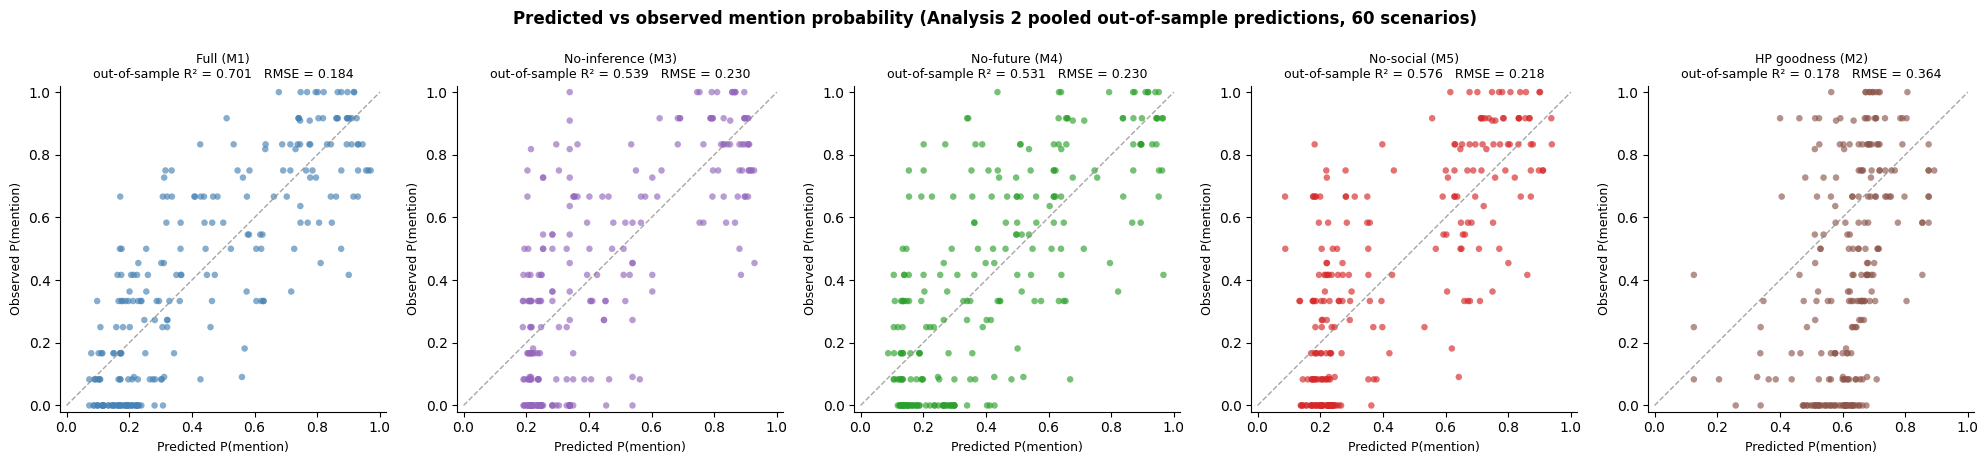

  wrote results/calibration_scatter_analysis2.png


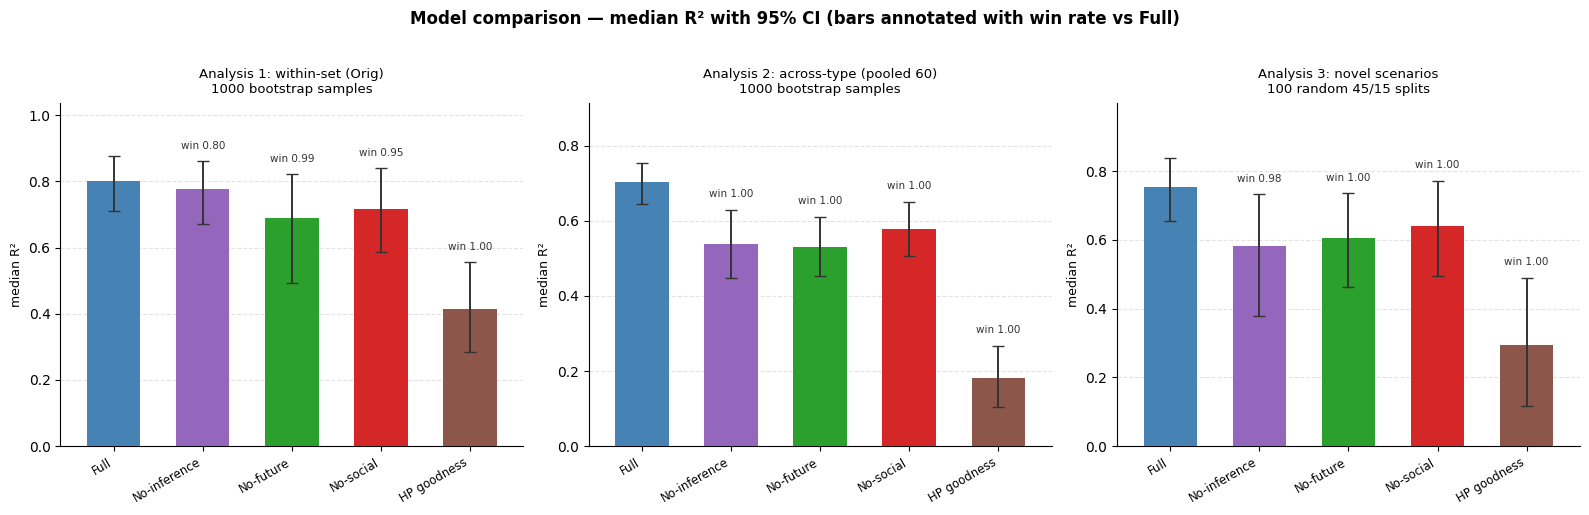

  wrote results/median_r2_by_analysis.png


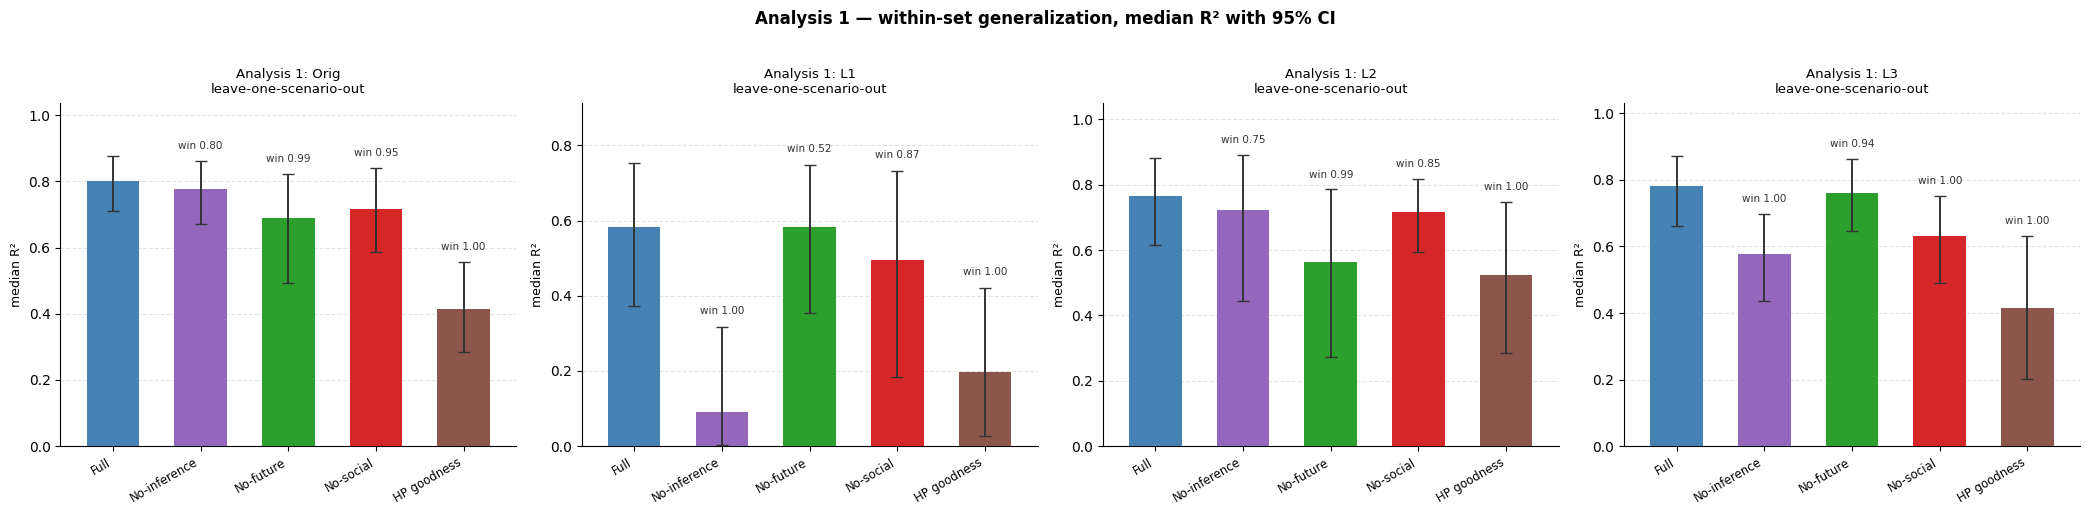

  wrote results/median_r2_analysis1_per_set.png


In [37]:
# ============================================================
# §6.1 — FIGURES
# Figure 1: predicted vs observed mention probability, one panel per model,
#   using the POOLED OUT-OF-SAMPLE predictions from Analysis 2, with the
#   identity line. This is how miscalibration becomes visible -- squared
#   Pearson r does not penalize compressed or offset predictions, so a model
#   can score well while its predictions cluster in a narrow band.
# Figure 2: median R² with 95% CI, one bar per model, one panel per analysis.
# ============================================================

# ── Figure 1: calibration scatter (Analysis 2 pooled out-of-sample) ───────────
fig1, axes1 = plt.subplots(1, len(MODEL_NAMES), figsize=(20, 4.2))
for ax, name, clr in zip(axes1, MODEL_NAMES, MODEL_COLORS):
    tbl      = a2_pooled[name]
    p, s     = tbl["preds"].ravel(), tbl["subjs"].ravel()
    r2, sgn  = r2_signed(tbl["preds"], tbl["subjs"])
    ax.scatter(p, s, color=clr, alpha=0.65, s=22, edgecolor="none")
    ax.plot([0, 1], [0, 1], "--", color="gray", lw=1.0, alpha=0.7)
    ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("Predicted P(mention)", fontsize=9)
    ax.set_ylabel("Observed P(mention)", fontsize=9)
    ax.set_title(f"{name} ({SPEC_MODEL_IDS[name]})\n"
                 f"out-of-sample R² = {r2:.3f}   RMSE = {rmse(tbl['preds'], tbl['subjs']):.3f}",
                 fontsize=9)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
fig1.suptitle("Predicted vs observed mention probability "
              "(Analysis 2 pooled out-of-sample predictions, 60 scenarios)",
              fontsize=12, fontweight="bold", y=1.04)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "calibration_scatter_analysis2.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"  wrote {RESULTS_DIR / 'calibration_scatter_analysis2.png'}")

# ── Figure 2: median R² with 95% CI, one panel per analysis ──────────────────
def _draw_median_bars(ax, dists, title, note=None):
    """Bar = median R²; error bars = 2.5/97.5 percentiles (spec §1.5).
    No significance stars: the spec forbids p-values on these distributions."""
    meds  = [summarize_r2(d)["median"] for d in dists]
    los   = [summarize_r2(d)["ci_lo"]  for d in dists]
    his   = [summarize_r2(d)["ci_hi"]  for d in dists]
    x     = np.arange(len(meds))
    yerr  = np.array([[m - lo for m, lo in zip(meds, los)],
                      [hi - m for m, hi in zip(meds, his)]])
    ax.bar(x, meds, color=MODEL_COLORS, zorder=3, width=0.6,
           yerr=yerr, capsize=4, error_kw=dict(lw=1.4, ecolor="#333333", zorder=4))

    # Annotate each alternative with its win rate against the Full model.
    for i in range(1, len(dists)):
        wr = compare_to_full(dists[0], dists[i])["win_rate"]
        ax.text(x[i], his[i] + 0.03, f"win {wr:.2f}", ha="center", va="bottom",
                fontsize=7.5, color="#333333")

    ax.set_xticks(x)
    ax.set_xticklabels(MODEL_NAMES, rotation=30, ha="right", fontsize=8.5)
    ax.set_ylabel("median R²", fontsize=9)
    ax.set_title(f"{title}\n{note}" if note else title, fontsize=9.5, pad=7)
    ax.set_xlim(-0.6, len(meds) - 0.4)
    ax.set_ylim(0, min(max(his) + 0.16, 1.10))
    ax.axhline(0, color="black", lw=0.6)
    ax.grid(axis="y", linestyle="--", alpha=0.35, zorder=0)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

fig2, axes2 = plt.subplots(1, 3, figsize=(16, 5))
_draw_median_bars(axes2[0], boot_r2_a1["Orig"],
                  "Analysis 1: within-set (Orig)", f"{N_BOOT} bootstrap samples")
_draw_median_bars(axes2[1], boot_a2,
                  "Analysis 2: across-type (pooled 60)", f"{N_BOOT} bootstrap samples")
_draw_median_bars(axes2[2], boot_r2_a3_splits,
                  "Analysis 3: novel scenarios", f"{N_SPLITS} random 45/15 splits")
fig2.suptitle("Model comparison — median R² with 95% CI "
              "(bars annotated with win rate vs Full)",
              fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "median_r2_by_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"  wrote {RESULTS_DIR / 'median_r2_by_analysis.png'}")

# ── Figure 3: Analysis 1, all four sets ──────────────────────────────────────
fig3, axes3 = plt.subplots(1, 4, figsize=(21, 5))
for ax, set_name in zip(axes3, ["Orig", "L1", "L2", "L3"]):
    _draw_median_bars(ax, boot_r2_a1[set_name],
                      f"Analysis 1: {set_name}", "leave-one-scenario-out")
fig3.suptitle("Analysis 1 — within-set generalization, median R² with 95% CI",
              fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "median_r2_analysis1_per_set.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"  wrote {RESULTS_DIR / 'median_r2_analysis1_per_set.png'}")

In [38]:
# ============================================================
# §7 — SANITY CHECKS
# Each check either passes silently or reports loudly. These are cheap and
# catch the failure modes that are invisible in aggregate results.
# ============================================================
_failures = []

def _check(label, condition, detail=""):
    if condition:
        print(f"  PASS  {label}")
    else:
        print(f"  FAIL  {label}  {detail}")
        _failures.append(label)

print("Sanity checks (spec §7)\n")

# 1. Every model saw identical fold/sample indices.
#    Indices are generated once per analysis and reused, so this compares the
#    hash of what was actually persisted against what the payloads recorded.
for set_name in per_set_loo:
    saved = np.load(FOLDS_DIR / f"analysis1_{set_name}_boot_idx.npy")
    _check(f"A1/{set_name}: bootstrap indices reproducible",
           idx_hash(saved) == a1_payload["sets"][set_name]["boot_idx_hash"])
_check("A2: bootstrap indices reproducible",
       idx_hash(np.load(FOLDS_DIR / "analysis2_boot_idx.npy")) == _h_a2)
_check("A3: split indices reproducible",
       idx_hash(np.load(FOLDS_DIR / "analysis3_split_idx.npy")) == idx_hash(_split_idx))

# 2. No scenario appears in both train and test within a split.
_bad_splits = [rep for rep in range(N_SPLITS)
               if set(_split_idx[rep][:15].tolist()) & set(_split_idx[rep][15:].tolist())]
_check("A3: no train/test overlap in any split", not _bad_splits, f"bad: {_bad_splits[:5]}")

# 3. Pooled prediction tables have exactly one prediction per scenario row.
for set_name, loo in per_set_loo.items():
    keys = loo["Full"]["keys"]
    _check(f"A1/{set_name}: one prediction per scenario",
           len(keys) == len(set(keys)), f"{len(keys)} rows, {len(set(keys))} unique")
_check("A2: one prediction per scenario (pooled 60)",
       len(a2_pooled["Full"]["keys"]) == len(set(a2_pooled["Full"]["keys"])))
_check("A2: pooled table covers all scenarios with data",
       a2_pooled["Full"]["preds"].shape[0] == _n_pooled)

# 4. sign(r) > 0 for all models on all evaluation sets.
_neg = []
for set_name, loo in per_set_loo.items():
    for name in MODEL_NAMES:
        sgn = r2_signed(loo[name]["preds"], loo[name]["subjs"])[1]
        if not np.isnan(sgn) and sgn < 0:
            _neg.append(f"A1/{set_name}/{name}")
for name in MODEL_NAMES:
    sgn = r2_signed(a2_pooled[name]["preds"], a2_pooled[name]["subjs"])[1]
    if not np.isnan(sgn) and sgn < 0:
        _neg.append(f"A2/{name}")
_check("sign(r) > 0 for all models on pooled predictions", not _neg, f"negative: {_neg}")

# 5. Ablation predictions actually differ from the Full model's.
#    A parameter-fixing bug that silently left the parameter free would make an
#    ablation identical to M1, which is easy to miss in aggregate results.
_identical = []
for name in MODEL_NAMES[1:]:
    if np.allclose(a2_pooled["Full"]["preds"], a2_pooled[name]["preds"], atol=1e-8):
        _identical.append(name)
_check("ablations differ from Full model", not _identical, f"identical to Full: {_identical}")

# 6. A constrained model cannot beat its unconstrained parent in-sample.
#    Fitting minimizes MSE, so the Full model's training loss must be <= each
#    nested lesion's on the same data. (HP goodness is a separate model, not
#    nested in M1, so it is excluded.)
_nested   = ["No-inference", "No-future", "No-social"]
_violations = []
for column, losses in train_losses.items():
    for name in _nested:
        if losses[name] < losses["Full"] - 1e-6:
            _violations.append(f"{column}/{name} ({losses[name]:.6f} < {losses['Full']:.6f})")
_check("nested lesions never fit better than Full in-sample",
       not _violations, f"optimizer failure: {_violations}")

print()
if _failures:
    print(f"{len(_failures)} SANITY CHECK(S) FAILED: {_failures}")
else:
    print("All sanity checks passed.")

Sanity checks (spec §7)

  PASS  A1/Orig: bootstrap indices reproducible
  PASS  A1/L1: bootstrap indices reproducible
  PASS  A1/L2: bootstrap indices reproducible
  PASS  A1/L3: bootstrap indices reproducible
  PASS  A2: bootstrap indices reproducible
  PASS  A3: split indices reproducible
  PASS  A3: no train/test overlap in any split
  PASS  A1/Orig: one prediction per scenario
  PASS  A1/L1: one prediction per scenario
  PASS  A1/L2: one prediction per scenario
  PASS  A1/L3: one prediction per scenario
  PASS  A2: one prediction per scenario (pooled 60)
  PASS  A2: pooled table covers all scenarios with data
  PASS  sign(r) > 0 for all models on pooled predictions
  PASS  ablations differ from Full model
  PASS  nested lesions never fit better than Full in-sample

All sanity checks passed.


Old CogSci data:  69 participants, 414 responses, N per stim: 34.5 ± 3.0
New remote data:  N per stim: 12.0 ± 0.0
Stimuli with data in both: 12/15

Correlation  r = 0.952,  R² = 0.907  (n = 48 points)


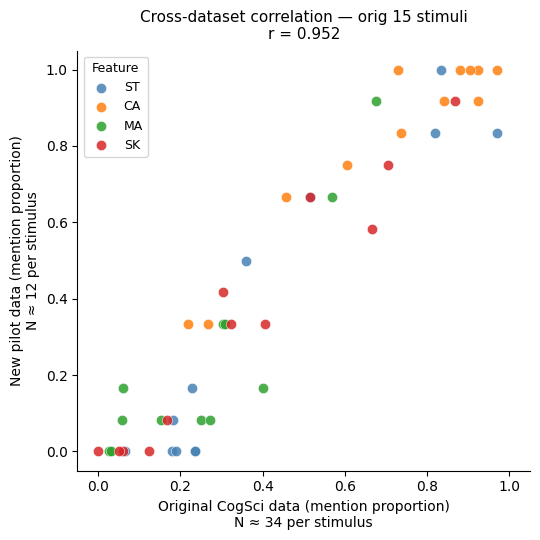

Saved corr_orig_old_vs_new.png


In [39]:
# ============================================================
# ORIG CROSS-DATASET CORRELATION
# Correlates new remote orig responses (data_proportions_orig)
# with the original CogSci experiment data (data/log.jsonl).
# Both cover the same 15 stimuli on the 6×9 map.
# Feature mention proportion = P(feature mentioned at all),
# computed directly from checkbox responses in both datasets.
# ============================================================

_LOG_OLD = "data/log.jsonl"

_OLD_KEYS = {
    "statement_bridge_burned": 0,   # ST
    "statement_need_cash":     1,   # CA
    "statement_yellow_closed": 2,   # MA
    "statement_bank_burned":   3,   # SK
}

# ── Load and parse old CogSci data ───────────────────────────────────────────
_old_counts = np.zeros((15, 4), dtype=float)
_old_total  = np.zeros(15,     dtype=float)
_n_old_subj = 0

try:
    with open(_LOG_OLD) as _fh:
        for _line in _fh:
            _line = _line.strip()
            if not _line:
                continue
            try:
                _row = json.loads(_line)
            except json.JSONDecodeError:
                continue
            if not isinstance(_row, list):
                continue
            _trials = [_r for _r in _row[1:-1]
                       if isinstance(_r, dict) and "stim" in _r]
            if not _trials:
                continue
            _n_old_subj += 1
            for _trial in _trials[3:]:          # first 3 rounds are practice
                _sid  = int(_trial["stim"])
                _resp = _trial.get("response", {})
                for _key, _fi in _OLD_KEYS.items():
                    if _key in _resp:
                        _old_counts[_sid, _fi] += 1
                _old_total[_sid] += 1
except FileNotFoundError:
    print(f"ERROR: {_LOG_OLD} not found — check path from explanations_fullstudy/")
    raise

_old_props = np.where(_old_total[:, None] > 0,
                      _old_counts / _old_total[:, None], np.nan)  # (15, 4)

print(f"Old CogSci data:  {_n_old_subj} participants, "
      f"{int(_old_total.sum())} responses, "
      f"N per stim: {_old_total[_old_total>0].mean():.1f} ± {_old_total[_old_total>0].std():.1f}")

# ── New remote orig data — marginalise utterance dist to feature mention rates
_new_props = np.array(data_proportions_orig) @ np.array(mention_matrix)  # (15, 4)

print(f"New remote data:  N per stim: "
      f"{data_n_orig[data_n_orig>0].mean():.1f} ± {data_n_orig[data_n_orig>0].std():.1f}")

# ── Align: only stims with data in both datasets ───────────────────────────────
_valid = ((_old_total > 0) & (data_n_orig > 0))
print(f"Stimuli with data in both: {_valid.sum()}/15")

_FEAT_NAMES  = ["ST", "CA", "MA", "SK"]
_FEAT_COLORS = ["steelblue", "tab:orange", "tab:green", "tab:red"]

_old_vec  = _old_props[_valid].ravel()    # (n_valid*4,)
_new_vec  = _new_props[_valid].ravel()
_feat_ids = np.tile(np.arange(4), _valid.sum())

_ok = ~(np.isnan(_old_vec) | np.isnan(_new_vec))
_old_c, _new_c, _fid_c = _old_vec[_ok], _new_vec[_ok], _feat_ids[_ok]

_r  = float(np.corrcoef(_old_c, _new_c)[0, 1])
_r2 = _r ** 2
print(f"\nCorrelation  r = {_r:.3f},  R² = {_r2:.3f}  (n = {len(_old_c)} points)")

# ── Scatter plot ───────────────────────────────────────────────────────────────
fig_c, ax_c = plt.subplots(figsize=(5.5, 5.5))

for _fi, (_fn, _fc) in enumerate(zip(_FEAT_NAMES, _FEAT_COLORS)):
    _m = _fid_c == _fi
    ax_c.scatter(_old_c[_m], _new_c[_m],
                 color=_fc, label=_fn, s=55, alpha=0.85, zorder=3,
                 edgecolors="white", linewidths=0.4)

# Identity line
# ax_c.plot([0, 1], [0, 1], "--", color="gray", lw=0.9, alpha=0.5, zorder=1)

# # OLS trendline
# _m_ols, _b_ols = np.polyfit(_old_c, _new_c, 1)
# _xs = np.linspace(_old_c.min(), _old_c.max(), 100)
# ax_c.plot(_xs, _m_ols * _xs + _b_ols, "-", color="black", lw=1.4, alpha=0.7, zorder=2)

ax_c.set_xlabel(
    f"Original CogSci data (mention proportion)\n"
    f"N ≈ {_old_total[_old_total>0].mean():.0f} per stimulus",
    fontsize=10)
ax_c.set_ylabel(
    f"New pilot data (mention proportion)\n"
    f"N ≈ {data_n_orig[data_n_orig>0].mean():.0f} per stimulus",
    fontsize=10)
ax_c.set_title(
    f"Cross-dataset correlation — orig 15 stimuli\n"
    f"r = {_r:.3f}",
    fontsize=11, pad=8)
ax_c.legend(title="Feature", loc="upper left", fontsize=9, title_fontsize=9)
ax_c.set_xlim(-0.05, 1.05)
ax_c.set_ylim(-0.05, 1.05)
ax_c.spines["top"].set_visible(False)
ax_c.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("corr_orig_old_vs_new.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved corr_orig_old_vs_new.png")
